In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""


📦 Cell: Catalog WormBase Files

In [2]:
# 🧬 Catalog WormBase Files Recursively (Safe Version)
import os
import pandas as pd

WORMBASE_DIR = "Downloads/wormbase_full_release"

FILE_TARGETS = {
    ".gff3": "Gene models, exons, transcripts",
    ".gtf": "Transcript models, splicing",
    ".fa": "Genome, transcriptome, CDS sequences",
    ".fasta": "Genome, transcriptome, CDS sequences",
    ".obo": "Ontologies (anatomy, development, GO)",
    ".json": "Annotations, metadata, expression",
    ".tsv": "Tables (expression, annotations)",
    ".csv": "Tables (expression, neuron x gene)",
    ".vcf": "Variants",
    ".txt": "Generic data",
    ".gz": "Compressed archive (may need inspection)",
    ".zip": "Compressed archive (manual extraction)",
    ".xml": "Structured metadata or models",
}

def identify_target(file):
    ext = os.path.splitext(file)[1].lower()
    return FILE_TARGETS.get(ext, "Unknown/Custom")

file_records = []
skipped_files = []

for root, _, files in os.walk(WORMBASE_DIR):
    for f in files:
        full_path = os.path.join(root, f)
        rel_path = os.path.relpath(full_path, WORMBASE_DIR)
        ext = os.path.splitext(f)[1].lower()
        try:
            size_mb = os.path.getsize(full_path) / 1_000_000
        except Exception as e:
            skipped_files.append((rel_path, str(e)))
            continue
        file_records.append({
            "RelativePath": rel_path,
            "Extension": ext,
            "Size_MB": round(size_mb, 2),
            "Suggested_Target": identify_target(f)
        })

wormbase_index_df = pd.DataFrame(file_records)

if wormbase_index_df.empty:
    print("⚠️ No files successfully scanned.")
else:
    wormbase_index_df.sort_values(by="Size_MB", ascending=False, inplace=True)
    wormbase_index_df.to_csv("wormbase_file_index.csv", index=False)
    print("✅ WormBase File Catalog Complete — top 10 largest files:")
    display(wormbase_index_df.head(10))

if skipped_files:
    print(f"⚠️ Skipped {len(skipped_files)} files due to read errors.")


✅ WormBase File Catalog Complete — top 10 largest files:


,RelativePath,Extension,Size_MB,Suggested_Target
559,hub/ws268.hal,.hal,2573.88,Unknown/Custom
38,database.297.4-16.tar.gz,.gz,1260.33,Compressed archive (may need inspection)
13,database.297.4-2.tar.gz,.gz,1038.95,Compressed archive (may need inspection)
42,database.297.4-12.tar.gz,.gz,1010.81,Compressed archive (may need inspection)
33,database.297.4-9.tar.gz,.gz,1008.72,Compressed archive (may need inspection)
41,database.297.4-11.tar.gz,.gz,989.72,Compressed archive (may need inspection)
51,database.297.4-13.tar.gz,.gz,980.32,Compressed archive (may need inspection)
12,database.297.4-15.tar.gz,.gz,963.42,Compressed archive (may need inspection)
937,hub/lod/ws268_lod_32.hal,.hal,907.23,Unknown/Custom
36,wormpep_clw.WS297.sql.gz,.gz,899.50,Compressed archive (may need inspection)


In [3]:
# 📊 Summary of file types
filetype_summary = wormbase_index_df.groupby("Extension").agg({
    "RelativePath": "count",
    "Size_MB": "sum"
}).rename(columns={"RelativePath": "FileCount"})

filetype_summary = filetype_summary.sort_values(by="Size_MB", ascending=False)
display(filetype_summary)


,FileCount,Size_MB
Extension,,
.gz,537,29349.70
.hal,6,4438.77
.wib,25,2717.48
.bb,240,801.03
.2bit,12,362.88
.wb,5,229.20
.bw,1,68.67
.obo,5,44.94
.dat,9,37.01


In [4]:
important_exts = [".tsv", ".csv", ".json", ".obo", ".gff3", ".gtf", ".xml", ".fa", ".txt"]

for ext in important_exts:
    subset = wormbase_index_df[wormbase_index_df["Extension"] == ext]
    if subset.empty:
        continue
    top_file = subset.sort_values(by="Size_MB", ascending=False).iloc[0]
    print(f"🔍 Top {ext} file — {top_file['Size_MB']} MB")
    print("📄", top_file["RelativePath"])
    print("📌 Target:", top_file["Suggested_Target"])
    print()


🔍 Top .json file — 0.02 MB
📄 ASSEMBLIES.WS297.json
📌 Target: Annotations, metadata, expression

🔍 Top .obo file — 35.01 MB
📄 gene_ontology.WS297.obo
📌 Target: Ontologies (anatomy, development, GO)

🔍 Top .txt file — 3.55 MB
📄 disease_association.by_orthology.WS297.tsv.txt
📌 Target: Generic data



In [5]:
import glob

# 🔍 Search for all .obo files recursively
obo_files = glob.glob(os.path.join(WORMBASE_DIR, "**/*.obo"), recursive=True)

if not obo_files:
    print("❌ No .obo files found.")
else:
    print(f"✅ Found {len(obo_files)} .obo files:")
    for f in obo_files:
        print("📄", f)


✅ Found 5 .obo files:
📄 Downloads/wormbase_full_release/gene_ontology.WS297.obo
📄 Downloads/wormbase_full_release/disease_ontology.WS297.obo
📄 Downloads/wormbase_full_release/anatomy_ontology.WS297.obo
📄 Downloads/wormbase_full_release/development_ontology.WS297.obo
📄 Downloads/wormbase_full_release/phenotype_ontology.WS297.obo


In [6]:
from pronto import Ontology

obo_paths = {
    "gene": "Downloads/wormbase_full_release/gene_ontology.WS297.obo",
    "disease": "Downloads/wormbase_full_release/disease_ontology.WS297.obo",
    "anatomy": "Downloads/wormbase_full_release/anatomy_ontology.WS297.obo",
    "development": "Downloads/wormbase_full_release/development_ontology.WS297.obo",
    "phenotype": "Downloads/wormbase_full_release/phenotype_ontology.WS297.obo"
}

ontologies = {}

for name, path in obo_paths.items():
    try:
        ont = Ontology(path)
        ontologies[name] = ont
        print(f"✅ Loaded '{name}' ontology with {len(ont.terms())} terms")
    except Exception as e:
        print(f"❌ Failed to load '{name}': {e}")


✅ Loaded 'gene' ontology with 48030 terms
✅ Loaded 'disease' ontology with 14339 terms
✅ Loaded 'anatomy' ontology with 7192 terms
✅ Loaded 'development' ontology with 777 terms
✅ Loaded 'phenotype' ontology with 2712 terms


In [ ]:
def search_neuron_terms(ontology, keyword="neuron"):
    return [
        term for term in ontology.terms()
        if term.name and keyword.lower() in term.name.lower()
    ]


In [ ]:
neuron_terms_anatomy = search_neuron_terms(ontologies["anatomy"])
print(f"🧠 Anatomy Ontology: {len(neuron_terms_anatomy)} neuron-related terms")
for t in neuron_terms_anatomy[:5]:
    print("•", t.id, "—", t.name)


In [ ]:
# 🔍 Extract neuron-related terms from all ontologies
all_neuron_terms = []

for name, ont in ontologies.items():
    terms = search_neuron_terms(ont, keyword="neuron")
    for t in terms:
        all_neuron_terms.append({
            "Ontology": name,
            "ID": t.id,
            "Name": t.name,
            "Definition": t.definition if t.definition else "",
        })

neuron_ontology_df = pd.DataFrame(all_neuron_terms)

# 📊 Summary
print("📐 Total neuron-related terms found:", len(neuron_ontology_df))
print("🔍 Counts per ontology:")
print(neuron_ontology_df['Ontology'].value_counts())

# 👁️ Preview
display(neuron_ontology_df.head(10))


In [ ]:
import os
import pandas as pd

EXTRA_DIR = "ExtraData"

# 🧠 Extend known targets if needed
EXTRA_FILE_TARGETS = {
    ".csv": "Tables (neuron/gene expression, annotations)",
    ".tsv": "Tables (synapses, structure, function)",
    ".xlsx": "Spreadsheets (manual curation, connectome data)",
    ".json": "Metadata, annotations",
    ".txt": "Freeform or tabular data",
    ".xml": "NeuroML, structured models",
    ".nml": "NeuroML morphologies or networks",
    ".png": "Neuron images, atlases",
    ".pdf": "Articles, manuals, documentation",
    ".py": "Simulation or parsing scripts",
    ".gz": "Compressed archives (check contents)",
}

def classify_extra_file(file):
    ext = os.path.splitext(file)[1].lower()
    return EXTRA_FILE_TARGETS.get(ext, "Unknown/Uncategorized")

extra_records = []
skipped = []

for root, _, files in os.walk(EXTRA_DIR):
    for f in files:
        full_path = os.path.join(root, f)
        rel_path = os.path.relpath(full_path, EXTRA_DIR)
        ext = os.path.splitext(f)[1].lower()
        try:
            size_mb = os.path.getsize(full_path) / 1_000_000
        except Exception as e:
            skipped.append((rel_path, str(e)))
            continue
        extra_records.append({
            "RelativePath": rel_path,
            "Extension": ext,
            "Size_MB": round(size_mb, 3),
            "Target": classify_extra_file(f)
        })

# 🧾 Build dataframe
extra_index_df = pd.DataFrame(extra_records)

if extra_index_df.empty:
    print("⚠️ No files found in ExtraData/")
else:
    extra_index_df.sort_values(by="Size_MB", ascending=False, inplace=True)
    extra_index_df.to_csv("extradata_file_index.csv", index=False)
    print(f"✅ Cataloged {len(extra_index_df)} files in ExtraData/")
    display(extra_index_df.head(10))

if skipped:
    print(f"⚠️ Skipped {len(skipped)} files due to read errors.")


In [ ]:
# 📥 Load and inspect all Excel files in ExtraData/
import os
import pandas as pd

EXTRA_DATA_DIR = "ExtraData"

# Supported Excel file types
excel_extensions = [".xls", ".xlsx"]

# File registry
excel_files = [
    os.path.join(EXTRA_DATA_DIR, f)
    for f in os.listdir(EXTRA_DATA_DIR)
    if os.path.splitext(f)[1].lower() in excel_extensions
]

# 🧠 Container for loaded DataFrames
extra_dataframes = {}
load_errors = []

# 📊 Load and inspect each Excel file
for file_path in excel_files:
    try:
        # Load all sheets to preview
        all_sheets = pd.read_excel(file_path, sheet_name=None)
        for sheet_name, df in all_sheets.items():
            key = f"{os.path.basename(file_path)} | {sheet_name}"
            extra_dataframes[key] = df
            print(f"✅ Loaded: {key}")
            print(f"📐 Shape: {df.shape}")
            print(f"🧬 Columns: {df.columns.tolist()}")
            print(df.head(3))
            print("-" * 80)
    except Exception as e:
        load_errors.append((file_path, str(e)))
        print(f"❌ Failed to load: {file_path} — {e}")

# 📌 Summary
print(f"\n📦 Total Excel sheets loaded: {len(extra_dataframes)}")
if load_errors:
    print(f"⚠️ Failed to load {len(load_errors)} files:")
    for path, err in load_errors:
        print(f"   • {path}: {err}")


In [ ]:
# 🧬 Classify extra_dataframes contents
from collections import defaultdict

# Summary table
summary = []

def classify_df(name, df):
    rows, cols = df.shape
    colnames = df.columns.astype(str).tolist()

    if rows == cols and all(df.index.astype(str) == df.columns.astype(str)):
        kind = "🧠 Symmetric Adjacency Matrix"
    elif any("neuron" in c.lower() for c in colnames) and df.shape[1] <= 4:
        kind = "🔗 Neuron Pair List"
    elif any("synapse" in c.lower() or "strength" in c.lower() for c in colnames):
        kind = "🧪 Synaptic Data"
    elif "relatedness" in colnames:
        kind = "🧬 Lineage Table"
    else:
        kind = "📄 Generic Attribute Table"

    return {
        "Sheet": name,
        "Rows": rows,
        "Cols": cols,
        "Columns": colnames[:5] + (["..."] if len(colnames) > 5 else []),
        "Classification": kind
    }

# 🧠 Apply classification
for name, df in extra_dataframes.items():
    summary.append(classify_df(name, df))

# 📑 Convert to DataFrame for review
extra_summary_df = pd.DataFrame(summary)
extra_summary_df = extra_summary_df.sort_values(by="Classification")

# 💾 Save summary
extra_summary_df.to_csv("ExtraData_Sheet_Classification.csv", index=False)

# 📋 Preview
print("✅ Summary of ExtraData contents:")
display(extra_summary_df)


In [ ]:
import os
import pandas as pd

# Define base directory (same as notebook)
BASE_DIR = os.getcwd()

# Define target extensions
TARGET_EXTENSIONS = {
    ".gz", ".tar", ".tar.gz", ".nml", ".xml",
    ".hal", ".bb", ".bw", ".wib", ".wb"
}

# Normalize extensions (some systems split .tar.gz into two)
def get_normalized_extension(filename):
    if filename.endswith(".tar.gz"):
        return ".tar.gz"
    return os.path.splitext(filename)[1]

# Recursively walk and collect file metadata
file_records = []
for root, _, files in os.walk(BASE_DIR):
    for file in files:
        ext = get_normalized_extension(file)
        if ext in TARGET_EXTENSIONS:
            full_path = os.path.join(root, file)
            try:
                size_mb = os.path.getsize(full_path) / (1024 * 1024)
            except Exception as e:
                size_mb = None
            file_records.append({
                "FilePath": os.path.relpath(full_path, BASE_DIR),
                "Extension": ext,
                "Size_MB": round(size_mb, 3) if size_mb is not None else None
            })

# Convert to DataFrame
unfleshed_files_df = pd.DataFrame(file_records)

# Sort by size for inspection
unfleshed_files_df = unfleshed_files_df.sort_values(by="Size_MB", ascending=False).reset_index(drop=True)

# Show summary
print(f"📦 Total unfleshed files found: {len(unfleshed_files_df)}")
display(unfleshed_files_df.head(20))


In [ ]:
# Optional breakdown
unfleshed_files_df["Extension"].value_counts()


In [ ]:
import os
import gzip
import tarfile
import shutil
from pathlib import Path
from multiprocessing import Pool, cpu_count
from tqdm.notebook import tqdm
import pandas as pd

# Settings
SEARCH_DIR = Path("Downloads/wormbase_full_release")  # adjust if needed
TARGET_EXTENSIONS = {".tar.gz", ".gz", ".xml", ".nml", ".hal", ".bb", ".bw", ".wib", ".wb", ".tar"}
EXTRACT_DIR = Path("ExtractedFiles")
EXTRACT_DIR.mkdir(exist_ok=True)

# Step 1: Find relevant files
file_records = []
for root, _, files in os.walk(SEARCH_DIR):
    for f in files:
        ext = "".join(Path(f).suffixes)
        if ext in TARGET_EXTENSIONS:
            full_path = Path(root) / f
            size_mb = full_path.stat().st_size / 1e6
            file_records.append({
                "FilePath": str(full_path),
                "Extension": ext,
                "Size_MB": round(size_mb, 3)
            })

df_files = pd.DataFrame(file_records)

# Step 2: Define extractor functions
def extract_file(row):
    path = Path(row["FilePath"])
    ext = row["Extension"]
    out_dir = EXTRACT_DIR / path.stem.replace('.', '_')  # Avoid collisions

    try:
        if out_dir.exists():
            return (str(path), "skipped (exists)")

        out_dir.mkdir(parents=True, exist_ok=True)

        if ext == ".gz" and not path.name.endswith(".tar.gz"):
            with gzip.open(path, 'rb') as f_in:
                out_file = out_dir / path.with_suffix('').name
                with open(out_file, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            return (str(path), "extracted .gz")

        elif ext in {".tar.gz", ".tar"}:
            with tarfile.open(path, 'r:*') as tar:
                tar.extractall(out_dir)
            return (str(path), "extracted .tar.gz")

        else:
            return (str(path), "no extraction needed")

    except Exception as e:
        return (str(path), f"failed: {str(e)}")

# Step 3: Multiprocessing with progress
with Pool(processes=cpu_count()) as pool:
    results = list(tqdm(pool.imap(extract_file, df_files.to_dict("records")), total=len(df_files)))

# Step 4: Summarize results
df_results = pd.DataFrame(results, columns=["FilePath", "Status"])
df_summary = df_results["Status"].value_counts()
print("✅ Extraction Summary:\n", df_summary)

# Optional: Merge with original
df_catalog = df_files.merge(df_results, on="FilePath")
df_catalog.head()


In [ ]:
import os
import pandas as pd
from lxml import etree
from multiprocessing import Pool, cpu_count
from pathlib import Path
from tqdm import tqdm
from functools import partial

# Step 1: Recursively find all .xml files
def find_all_xml_files(base_dir="."):
    xml_paths = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(".xml"):
                full_path = os.path.join(root, file)
                xml_paths.append(full_path)
    return xml_paths

# Step 2: XML parser for each file
def parse_xml(file_path):
    records = []
    try:
        tree = etree.parse(file_path)
        root = tree.getroot()
        for elem in root.iter():
            tag = elem.tag
            attrs = dict(elem.attrib)
            text = elem.text.strip() if elem.text else ""
            records.append({
                "FilePath": file_path,
                "Tag": tag,
                "Attributes": attrs,
                "Text": text
            })
    except Exception as e:
        records.append({
            "FilePath": file_path,
            "Tag": "PARSE_ERROR",
            "Attributes": {},
            "Text": str(e)
        })
    return records

# Step 3: Wrapper for parallel parsing with progress bar
def parse_all_xml_files(xml_file_list):
    parsed_data = []
    with Pool(processes=cpu_count()) as pool:
        for file_records in tqdm(pool.imap_unordered(parse_xml, xml_file_list), total=len(xml_file_list), desc="🔍 Parsing XML"):
            parsed_data.extend(file_records)
    return parsed_data

# Execute all steps
base_dir = "."  # Change if your root directory is different
xml_files = find_all_xml_files(base_dir)
print(f"📂 Found {len(xml_files)} XML files")

# Parse them in parallel
parsed_records = parse_all_xml_files(xml_files)

# Convert to DataFrame
df_xml = pd.DataFrame(parsed_records)

# Save or display results
print(f"✅ Parsed {len(df_xml)} XML elements from {len(xml_files)} files")
display(df_xml.head(10))

# Summary: Tag frequency
tag_summary = df_xml["Tag"].value_counts().reset_index()
tag_summary.columns = ["Tag", "Count"]
print("\n📊 Top Tags Found:")
display(tag_summary.head(20))


In [ ]:
# --- Prerequisites ---
import pandas as pd

# df_xml should already be available
assert 'df_xml' in globals(), "❌ df_xml not found. Run the XML parsing step first."

# --- 1. Morphology: Extract MorphML structural components ---
morph_df = df_xml[df_xml['Tag'].str.contains('morphml|segment|proximal|distal|cable', na=False)].copy()
morph_df['Neuron'] = morph_df['FilePath'].str.extract(r'/([^/]+)\.morph\.xml', expand=False)

# Parse coordinates and cable info
morph_coords = morph_df[morph_df['Tag'].str.contains('proximal|distal', na=False)].copy()
morph_coords[['x', 'y', 'z', 'diameter']] = morph_coords['Attributes'].apply(lambda attr: pd.Series({
    k: float(attr.get(k, 0)) for k in ['x', 'y', 'z', 'diameter']
}))

# --- 2. Channels & Synapses: ChannelML elements ---
channel_df = df_xml[df_xml['Tag'].str.contains('channelml|synapse_type|doub_exp_syn', na=False)].copy()
channel_df['MechanismName'] = channel_df['Attributes'].apply(lambda x: x.get('name', '') if isinstance(x, dict) else '')
channel_df['Params'] = channel_df['Attributes'].apply(lambda d: {k: v for k, v in d.items() if k != 'name'} if isinstance(d, dict) else {})

# --- 3. Network Connectivity: NetworkML elements ---
net_df = df_xml[df_xml['Tag'].str.contains('networkml|connection|projection|synapse_props', na=False)].copy()

# Simplify connection info
connection_df = net_df[net_df['Tag'].str.contains('connection', na=False)].copy()
connection_df['Pre'] = connection_df['Attributes'].apply(lambda d: d.get('pre_cell_id', '') if isinstance(d, dict) else '')
connection_df['Post'] = connection_df['Attributes'].apply(lambda d: d.get('post_cell_id', '') if isinstance(d, dict) else '')
connection_df['Weight'] = connection_df['Attributes'].apply(lambda d: d.get('weight', '') if isinstance(d, dict) else '')

# --- 4. Notes, Contributors, Comments ---
meta_df = df_xml[df_xml['Tag'].str.contains('contributor|notes|comment|name', na=False)].copy()
meta_df = meta_df[['FilePath', 'Tag', 'Text']].dropna().reset_index(drop=True)

# --- Summary Prints ---
print(f"✅ Morphology segments: {len(morph_coords)}")
print(f"✅ Synaptic/channel mechanisms: {len(channel_df)}")
print(f"✅ NetworkML connections: {len(connection_df)}")
print(f"✅ Metadata entries (notes/contributors): {len(meta_df)}")

# --- Final Output DataFrames ---
morph_coords_df = morph_coords[['FilePath', 'Neuron', 'Tag', 'x', 'y', 'z', 'diameter']]
channel_summary_df = channel_df[['FilePath', 'Tag', 'MechanismName', 'Params']]
connection_summary_df = connection_df[['FilePath', 'Tag', 'Pre', 'Post', 'Weight']]
meta_summary_df = meta_df

# Preview summaries manually
display(morph_coords_df.head())
display(channel_summary_df.head())
display(connection_summary_df.head())
display(meta_summary_df.head())



In [ ]:
morph_coords_df.to_csv("out_morphology_segments.csv", index=False)
channel_summary_df.to_csv("out_synaptic_mechanisms.csv", index=False)
connection_summary_df.to_csv("out_network_connections.csv", index=False)
meta_summary_df.to_csv("out_metadata_notes.csv", index=False)


In [ ]:
import os
import xml.etree.ElementTree as ET
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import pandas as pd

# 📁 Change this to your project root if needed
PROJECT_ROOT = os.getcwd()

# 🔍 Step 1: Find all .nml files
nml_files = []
for root, _, files in os.walk(PROJECT_ROOT):
    for file in files:
        if file.endswith(".nml"):
            nml_files.append(os.path.join(root, file))

print(f"📂 Found {len(nml_files)} NML files")

# 🧠 Step 2: Parser for each file
def parse_nml_file(filepath):
    elements = []
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        for elem in root.iter():
            tag = elem.tag
            attrib = elem.attrib
            text = elem.text.strip() if elem.text and elem.text.strip() else ""
            elements.append({
                "FilePath": filepath,
                "Tag": tag,
                "Attributes": attrib,
                "Text": text
            })
    except Exception as e:
        elements.append({
            "FilePath": filepath,
            "Tag": "ERROR",
            "Attributes": {},
            "Text": str(e)
        })
    return elements

# ⚡ Step 3: Parallel processing with progress
with Pool(cpu_count()) as pool:
    all_nml_elements = list(tqdm(pool.imap_unordered(parse_nml_file, nml_files), total=len(nml_files)))

# Flatten results
flat_nml_data = [item for sublist in all_nml_elements for item in sublist]
nml_df = pd.DataFrame(flat_nml_data)

# 📊 Summary of top tags
tag_counts = nml_df['Tag'].value_counts().reset_index()
tag_counts.columns = ['Tag', 'Count']

print(f"✅ Parsed {len(nml_df)} NML elements from {len(nml_files)} files")
print("\n📊 Top Tags Found in NML Files:")
print(tag_counts.head(20))

# Optional save
nml_df.to_csv("out_nml_parsed_elements.csv", index=False)


In [ ]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

# --- STEP 1: Locate all NML files ---
nml_files = []
for root, _, files in os.walk("."):
    for f in files:
        if f.lower().endswith(".nml"):
            nml_files.append(os.path.join(root, f))

print(f"📂 Found {len(nml_files)} .nml files")

# --- STEP 2: Parsing function ---
def parse_nml_file(path):
    results = []
    try:
        tree = ET.parse(path)
        root = tree.getroot()
        for elem in root.iter():
            tag = elem.tag
            attrs = elem.attrib
            text = (elem.text or "").strip()

            row = {
                "FilePath": path,
                "Tag": tag,
                "Attributes": str(attrs),
                "Text": text
            }

            # Extract likely neuron-related fields if present
            for field in ['Pre', 'Post', 'Neuron', 'Source', 'Target']:
                row[field] = attrs.get(field)

            results.append(row)
    except Exception as e:
        results.append({
            "FilePath": path,
            "Tag": "ERROR",
            "Attributes": str(e),
            "Text": "",
            "Pre": None,
            "Post": None,
            "Neuron": None,
            "Source": None,
            "Target": None
        })
    return results

# --- STEP 3: Multiprocessing parse ---
with Pool(cpu_count()) as pool:
    parsed = list(tqdm(pool.imap_unordered(parse_nml_file, nml_files), total=len(nml_files)))

# Flatten and convert to DataFrame
flat_data = [item for sublist in parsed for item in sublist]
nml_elements_df = pd.DataFrame(flat_data)

# --- STEP 4: Save for reuse ---
nml_elements_df.to_csv("nml_results.csv", index=False)
print(f"✅ Parsed {len(nml_elements_df)} XML elements from {len(nml_files)} NML files")


In [ ]:
import os
import pandas as pd
import re
from tqdm import tqdm

# --- STEP 1: Load or parse nml_elements_df ---
if not 'nml_elements_df' in locals():
    if os.path.exists("nml_results.csv"):
        nml_elements_df = pd.read_csv("nml_results.csv")
        print(f"✅ Loaded nml_elements_df from nml_results.csv")
    else:
        raise ValueError("❌ nml_elements_df not defined and nml_results.csv not found.")

# --- STEP 2: Construct network_summary_df ---
network_tags = [
    "{http://morphml.org/networkml/schema}connection",
    "{http://morphml.org/networkml/schema}projection",
    "{http://morphml.org/networkml/schema}connections"
]

network_summary_df = nml_elements_df[nml_elements_df["Tag"].isin(network_tags)].copy()

for field in ["Pre", "Post", "Source", "Target", "Neuron"]:
    if field not in network_summary_df.columns:
        network_summary_df[field] = None

# --- STEP 3: Load existing parsed XML summaries ---
# These should already exist from your previous XML parsing cell
required_dfs = ["morph_coords_df", "channel_summary_df"]
for df_name in required_dfs:
    if df_name not in locals():
        raise NameError(f"❌ Required DataFrame '{df_name}' not defined in notebook.")

# --- STEP 4: Extract neuron names from XML ---
xml_neurons = set()

for i, row in morph_coords_df.iterrows():
    name = str(row.get("Neuron", "")).strip()
    if name:
        xml_neurons.add(name)

for i, row in channel_summary_df.iterrows():
    mech = row.get("MechanismName", "")
    if mech and "neuron" in mech.lower():
        xml_neurons.add(mech.strip())

for col in ["Pre", "Post"]:
    if col in network_summary_df.columns:
        xml_neurons.update(network_summary_df[col].dropna().astype(str).str.strip())

# --- STEP 5: Extract neuron names from NML ---
nml_neurons = set()

for i, row in nml_elements_df.iterrows():
    for field in ['Pre', 'Post', 'Neuron', 'Source', 'Target']:
        if field in row:
            name = row[field]
            if isinstance(name, str) and name.strip():
                nml_neurons.add(name.strip())
    # Also search in raw attribute string
    attrs = str(row.get("Attributes", ""))
    matches = re.findall(r"'(.*?)'", attrs)
    for m in matches:
        if re.match(r'^[A-Z]{2,4}[LR]?', m):  # crude neuron name pattern
            nml_neurons.add(m.strip())

# --- STEP 6: Normalize ---
def clean(name):
    return name.strip().replace(".cell", "").replace("Neuron_", "")

xml_neurons = set(map(clean, xml_neurons))
nml_neurons = set(map(clean, nml_neurons))

# --- STEP 7: Compare ---
common_neurons = xml_neurons & nml_neurons
only_in_xml = xml_neurons - nml_neurons
only_in_nml = nml_neurons - xml_neurons

print(f"🧠 Neurons in both XML & NML: {len(common_neurons)}")
print(f"📄 Only in XML: {len(only_in_xml)}")
print(f"📁 Only in NML: {len(only_in_nml)}")

# --- STEP 8: DataFrame Output ---
comparison_df = pd.DataFrame({
    "Common": pd.Series(sorted(common_neurons)),
    "OnlyInXML": pd.Series(sorted(only_in_xml)),
    "OnlyInNML": pd.Series(sorted(only_in_nml)),
})

comparison_df.head(30)


In [ ]:
import os, gzip, tarfile
import pandas as pd
from tqdm.auto import tqdm
from multiprocessing import Pool, cpu_count
from pathlib import Path

# File types to parse
target_exts = [".tar", ".tar.gz", ".gz", ".hal", ".bb", ".bw", ".wib", ".wb", ".json", ".txt", ".csv", ".tsv"]

# Root directory
ROOT_DIR = Path(".")  # adjust if needed

# Recursive file search
all_files = []
for ext in target_exts:
    all_files.extend(list(ROOT_DIR.rglob(f"*{ext}")))

# Parser function
def inspect_file(filepath):
    path = Path(filepath)
    size_mb = round(path.stat().st_size / 1024**2, 3)
    ext = path.suffix.lower()

    summary = {"FilePath": str(path), "Extension": ext, "Size_MB": size_mb, "Preview": None}

    try:
        if ext in [".gz"]:
            with gzip.open(path, "rt", errors="ignore") as f:
                lines = [next(f) for _ in range(5)]
                summary["Preview"] = "".join(lines)

        elif ext in [".tar", ".tar.gz"]:
            with tarfile.open(path, "r:*") as tar:
                members = tar.getmembers()
                summary["Preview"] = f"{len(members)} files: " + ", ".join(m.name for m in members[:3])

        elif ext == ".hal":
            summary["Preview"] = "HAL format: binary alignment file. Use halStats externally."

        elif ext in [".json", ".txt", ".csv", ".tsv"]:
            with open(path, "r", errors="ignore") as f:
                lines = [next(f) for _ in range(5)]
                summary["Preview"] = "".join(lines)

        elif ext in [".bb", ".bw", ".wib", ".wb"]:
            summary["Preview"] = "Binary genomic format. Use pyBigWig or UCSC tools."

        else:
            summary["Preview"] = "Unsupported or unknown format."

    except Exception as e:
        summary["Preview"] = f"❌ Error: {e}"

    return summary

# Multiprocessing scan
with Pool(cpu_count()) as pool:
    results = list(tqdm(pool.imap(inspect_file, all_files), total=len(all_files), desc="🔍 Scanning other file types"))

# Create DataFrame
other_files_df = pd.DataFrame(results)
print(f"✅ Parsed {len(other_files_df)} files.")
other_files_df.head(10)


In [ ]:
import os
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import gzip, tarfile
import shutil

from csv import QUOTE_ALL

# --- Parameters ---
ROOT_DIR = "Downloads/wormbase_full_release"
TARGET_EXTS = [".gz", ".tar", ".tar.gz", ".hal", ".bb", ".bw", ".wib", ".wb", ".xml"]
MAX_LINES = 5
CATALOG_NAME = "extra_file_catalog.csv"

# --- Step 1: Find relevant files ---
file_info = []

for ext in TARGET_EXTS:
    file_paths = list(Path(ROOT_DIR).rglob(f"*{ext}"))
    for path in file_paths:
        try:
            size_mb = round(path.stat().st_size / (1024 * 1024), 3)
        except:
            size_mb = None
        file_info.append({
            "FilePath": str(path),
            "Extension": path.suffix.lower(),
            "Size_MB": size_mb
        })

extra_df = pd.DataFrame(file_info)
print(f"📁 Found {len(extra_df)} files with target extensions.")

# --- Step 2: Define safe preview logic ---
def preview_file_contents(filepath, ext, max_lines=5):
    try:
        if ext.endswith(".gz"):
            with gzip.open(filepath, "rt", errors="ignore") as f:
                return "\n".join([next(f).strip() for _ in range(max_lines)])
        elif ext in [".tar", ".tar.gz"]:
            with tarfile.open(filepath, "r:*") as tar:
                return "TAR contents:\n" + "\n".join([m.name for m in tar.getmembers()[:max_lines]])
        elif ext in [".hal", ".bb", ".bw", ".wib", ".wb"]:
            return f"Binary file type ({ext}) — preview not attempted"
        elif ext == ".xml":
            with open(filepath, "r", errors="ignore") as f:
                return "\n".join([next(f).strip() for _ in range(max_lines)])
        else:
            with open(filepath, "r", errors="ignore") as f:
                return "\n".join([next(f).strip() for _ in range(max_lines)])
    except Exception as e:
        return f"⚠️ Error: {str(e)}"

# --- Step 3: Apply preview with progress bar ---
tqdm.pandas(desc="🔍 Previewing")
extra_df["Preview"] = extra_df["FilePath"].progress_apply(lambda p: preview_file_contents(p, Path(p).suffix.lower(), max_lines=MAX_LINES))

# --- Step 4: Save safely with quoting/escaping ---
try:
    extra_df.to_csv(
        CATALOG_NAME,
        index=False,
        escapechar="\\",
        quoting=QUOTE_ALL  # Quote everything to avoid CSV parse issues
    )
    print(f"✅ Saved full catalog to {CATALOG_NAME}")
except Exception as e:
    print(f"❌ Failed to save CSV: {str(e)}")

# --- Optional: Preview top few entries ---
display_cols = ["FilePath", "Extension", "Size_MB", "Preview"]
print(extra_df[display_cols].head(10).to_string(index=False))


In [ ]:
# 📦 Full Wormbase Scan + Preview + Scoring + Safe CSV
import os
import pandas as pd
import gzip, tarfile, csv
from pathlib import Path
from tqdm.contrib.concurrent import process_map

# ✅ Actual root directory to scan (update if needed)
ROOT_DIR = Path("Downloads/wormbase_full_release")
TARGET_EXTS = [".gz", ".tar", ".tar.gz", ".bb", ".bw", ".wib", ".wb", ".hal", ".xml"]
MAX_PREVIEW_LINES = 5

# --- Recursive scan for files with target extensions ---
all_files = []
for path in ROOT_DIR.rglob("*"):
    if path.is_file() and any("".join(path.suffixes[-2:]).endswith(ext) or path.suffix.endswith(ext) for ext in TARGET_EXTS):
        all_files.append(path)

print(f"📁 Found {len(all_files)} files with target extensions.")

# --- Preview function ---
def preview_file(path):
    ext = "".join(path.suffixes[-2:]) if path.suffixes[-1] == ".gz" else path.suffix
    size = round(path.stat().st_size / 1024**2, 3)
    preview = ""
    try:
        if ext.endswith(".gz") and not ext.endswith(".tar.gz"):
            with gzip.open(path, 'rt', encoding='utf-8', errors='ignore') as f:
                preview = "\n".join([next(f).strip() for _ in range(MAX_PREVIEW_LINES)])
        elif ext == ".xml":
            with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                preview = "\n".join([next(f).strip() for _ in range(MAX_PREVIEW_LINES)])
        elif ext == ".tar" or ext == ".tar.gz":
            with tarfile.open(path, 'r:*') as tar:
                preview = ", ".join([m.name for m in tar.getmembers()[:5]])
        else:
            with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                preview = "\n".join([next(f).strip() for _ in range(MAX_PREVIEW_LINES)])
    except Exception as e:
        preview = f"[Unreadable: {type(e).__name__}]"
    return {
        "FilePath": str(path),
        "Extension": ext,
        "Size_MB": size,
        "Preview": preview
    }

# --- Run preview with multiprocessing ---
print("🔍 Previewing contents...")
catalog = process_map(preview_file, all_files, max_workers=8, chunksize=10)
df = pd.DataFrame(catalog)

# --- Relevance scoring ---
def score_file(row):
    text = row["FilePath"] + " " + row["Preview"]
    score = 0
    if "neuron" in text.lower(): score += 2
    if "synapse" in text.lower(): score += 2
    if "connectome" in text.lower(): score += 2
    if "morphology" in text.lower(): score += 2
    if any(x in text.lower() for x in ["xml", "nml", "channel", "projection", "networkml"]): score += 1
    if row["Extension"] in [".xml", ".hal", ".tar.gz", ".wb"]: score += 1
    return score

df["RelevanceScore"] = df.apply(score_file, axis=1)

# --- Save safely to CSV ---
df.to_csv("extra_file_catalog.csv", index=False, escapechar='\\', quoting=csv.QUOTE_ALL)
print("✅ Saved full catalog to extra_file_catalog.csv")

# --- Show summary ---
summary = df.groupby("Extension").agg(
    Count=("FilePath", "count"),
    Total_MB=("Size_MB", "sum"),
    AvgScore=("RelevanceScore", "mean"),
    MaxScore=("RelevanceScore", "max")
).sort_values("Count", ascending=False)

from IPython.display import display
display(summary)


In [ ]:
import os
import tarfile
import pandas as pd
from tqdm import tqdm
from pathlib import Path

tar_paths = []
for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".tar.gz"):
            tar_paths.append(os.path.join(root, f))

print(f"📦 Found {len(tar_paths)} .tar.gz files.")

catalog = []

# Only read headers, don't extract
for tar_path in tqdm(tar_paths):
    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            for m in tar.getmembers():
                if m.isfile():
                    catalog.append({
                        "TarSource": tar_path,
                        "FileName": os.path.basename(m.name),
                        "FilePath": m.name,
                        "Extension": Path(m.name).suffix.lower(),
                        "Size_KB": m.size / 1024
                    })
    except Exception as e:
        print(f"❌ Error reading {tar_path}: {e}")

# Save catalog
df = pd.DataFrame(catalog)
df.to_csv("tar_contents_catalog.csv", index=False)
print("✅ Saved tar contents to tar_contents_catalog.csv")

# Summary
summary = df.groupby("Extension").agg(
    Count=("FilePath", "count"),
    Total_KB=("Size_KB", "sum")
)
print("\n", summary.sort_values("Total_KB", ascending=False))


In [ ]:
import os
import tarfile
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# Load catalog
catalog = pd.read_csv("tar_contents_catalog.csv")
txt_df = catalog[catalog["Extension"] == ".txt"].copy()

print(f"📄 Found {len(txt_df)} .txt files across {txt_df['TarSource'].nunique()} archives.")

# Create output dir
EXTRACT_DIR = Path("./_extracted_txt")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Group by archive for efficient access
grouped = txt_df.groupby("TarSource")

# Extract per archive
for tar_path, group in tqdm(grouped, desc="📦 Extracting .txt files"):
    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            members = []
            for _, row in group.iterrows():
                try:
                    members.append(tar.getmember(row["FilePath"]))
                except KeyError:
                    print(f"⚠️ Skipping missing member: {row['FilePath']} in {tar_path}")
            # Output directory
            outdir = EXTRACT_DIR / Path(tar_path).stem.replace(".tar", "")
            outdir.mkdir(parents=True, exist_ok=True)
            tar.extractall(path=outdir, members=members)
    except Exception as e:
        print(f"❌ Error extracting from {tar_path}: {e}")

print("✅ Done extracting all .txt files.")


In [ ]:
from pathlib import Path

TXT_ROOT = Path("./_extracted_txt")
txt_files = list(TXT_ROOT.rglob("*.txt"))
print(f"📄 Found {len(txt_files)} .txt files for parsing.")


In [ ]:
import pandas as pd

parsed_dfs = []

for path in tqdm(txt_files, desc="🔍 Parsing .txt files"):
    try:
        # Try auto-detecting delimiter
        df = pd.read_csv(path, sep=None, engine="python")
        df["__SourceFile"] = str(path)
        parsed_dfs.append(df)
    except Exception as e:
        print(f"⚠️ Could not parse {path.name}: {e}")

# Combine all
if parsed_dfs:
    merged_df = pd.concat(parsed_dfs, ignore_index=True)
    merged_df.to_csv("parsed_txt_merged.csv", index=False)
    print(f"✅ Parsed and saved {len(parsed_dfs)} files into parsed_txt_merged.csv")
else:
    print("❌ No valid .txt files parsed.")


In [ ]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import csv

# Already parsed files from step A
parsed_paths = set(Path(f) for f in pd.read_csv("parsed_txt_merged.csv")["__SourceFile"].unique())

# All .txt files
all_txt_files = list(Path("./_extracted_txt").rglob("*.txt"))
unparsed_txt_files = [f for f in all_txt_files if f not in parsed_paths]

print(f"🧪 Attempting salvage on {len(unparsed_txt_files)} unparsed files...")

salvaged_dfs = []

for path in tqdm(unparsed_txt_files, desc="🛠️ Salvaging .txt files"):
    try:
        # Detect delimiter
        with open(path, 'r') as f:
            sample = f.read(4096)
            delimiter = csv.Sniffer().sniff(sample).delimiter

        # Attempt robust load
        df = pd.read_csv(
            path,
            sep=delimiter,
            header=0,
            engine='python',
            on_bad_lines='warn',  # pandas ≥1.3+
            dtype=str  # prevents dtype errors
        )

        df["__SourceFile"] = str(path)
        salvaged_dfs.append(df)

    except Exception as e:
        print(f"❌ Still failed: {path.name} → {e}")

# Merge and save
if salvaged_dfs:
    salvaged_merged = pd.concat(salvaged_dfs, ignore_index=True)
    salvaged_merged.to_csv("parsed_txt_salvaged.csv", index=False)
    print(f"✅ Salvaged and saved {len(salvaged_dfs)} files to parsed_txt_salvaged.csv")
else:
    print("❌ No salvageable files.")


In [ ]:
df_clean = pd.read_csv("parsed_txt_merged.csv", dtype=str)
df_salvaged = pd.read_csv("parsed_txt_salvaged.csv", dtype=str)

# Unified dataset
df_all = pd.concat([df_clean, df_salvaged], ignore_index=True)
df_all.to_csv("parsed_txt_all.csv", index=False)

print(f"✅ Combined total: {len(df_all)} rows across {df_all['__SourceFile'].nunique()} files.")


In [ ]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm

# All .txt files
txt_files = list(Path("./_extracted_txt").rglob("*.txt"))
clean_dfs = []

for path in tqdm(txt_files, desc="🧽 Re-parsing without headers"):
    try:
        # Read as raw table without assuming header
        df = pd.read_csv(path, sep=None, engine="python", header=None, dtype=str)
        df["__SourceFile"] = str(path)
        clean_dfs.append(df)
    except Exception as e:
        print(f"❌ {path.name} → {e}")

# Combine
clean_raw = pd.concat(clean_dfs, ignore_index=True)
clean_raw.to_csv("parsed_txt_raw.csv", index=False)

print(f"✅ Re-parsed {len(clean_dfs)} files into parsed_txt_raw.csv ({len(clean_raw)} rows).")


In [ ]:
import pandas as pd
from collections import Counter

df = pd.read_csv("parsed_txt_raw.csv", dtype=str)

# Drop __SourceFile column temporarily
content_df = df.drop(columns=["__SourceFile"])

# Count number of columns per row (after drop)
row_lengths = content_df.apply(lambda row: row.first_valid_index() or len(row), axis=1)
row_lengths = content_df.apply(lambda row: row.count(), axis=1)

# Group and count
schema_counts = Counter(row_lengths)

# Display schema profile
print("🧩 Row-wise Schema Lengths:")
for length, count in sorted(schema_counts.items()):
    print(f" - Rows with {length} columns: {count} rows")


In [ ]:
import pandas as pd

# Reload full data to be safe
df = pd.read_csv("parsed_txt_raw.csv", dtype=str)

# Identify rows with exactly 3 non-null values (excluding __SourceFile)
df_3col = df[df.drop(columns="__SourceFile").apply(lambda r: r.count(), axis=1) == 3].copy()

# Get only the 3 populated columns + source
value_cols = df_3col.drop(columns="__SourceFile").apply(lambda row: row[row.notna()].tolist(), axis=1)
df_3col_clean = pd.DataFrame(value_cols.tolist(), columns=["Col1", "Col2", "Col3"])
df_3col_clean["__SourceFile"] = df_3col["__SourceFile"].values

# Preview
print("🔍 Sample of cleaned 3-column rows:")
print(df_3col_clean.head())


In [ ]:
# For each source file, show top unique values in Col2 (the middle column)
grouped = df_3col_clean.groupby("__SourceFile")

for source, group in grouped:
    tags = group["Col2"].value_counts().head(5)
    print(f"📁 {source}")
    print("🔖 Top Col2 field tags:", list(tags.index))
    print()


In [ ]:
# Try to identify signal data by checking if Col2 and Col3 are numeric
def is_numeric(val):
    try:
        float(val)
        return True
    except:
        return False

# Add flags to check numeric status
df_3col_clean["Col2_numeric"] = df_3col_clean["Col2"].apply(is_numeric)
df_3col_clean["Col3_numeric"] = df_3col_clean["Col3"].apply(is_numeric)

# Filter for likely signal traces (numeric in Col2 & Col3)
df_signals = df_3col_clean[df_3col_clean["Col2_numeric"] & df_3col_clean["Col3_numeric"]].copy()

# Show examples
print("🧠 Sample likely signal trace rows:")
print(df_signals[["Col1", "Col2", "Col3", "__SourceFile"]].head())

# Count unique files with signal traces
print(f"\n📦 Signal traces found in {df_signals['__SourceFile'].nunique()} files.")


In [ ]:
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

# Load raw parsed dataset
df = pd.read_csv("parsed_txt_raw.csv", dtype=str)
df_no_source = df.drop(columns=["__SourceFile"])

# Helper: classify value type
def infer_type(val):
    try:
        float(val)
        return "numeric"
    except:
        return "string"

# Group rows by actual column count
row_groups = defaultdict(list)

for idx, row in tqdm(df.iterrows(), total=len(df)):
    row_data = row.drop(labels="__SourceFile").dropna()
    n_cols = len(row_data)
    row_groups[n_cols].append((row_data.tolist(), row["__SourceFile"]))

# Loop through each schema
for n_cols, rows in sorted(row_groups.items()):
    print(f"\n🔍 Schema with {n_cols} columns — {len(rows)} rows")
    
    # Unique file sources
    sources = {r[1] for r in rows}
    print(f"📂 Found in {len(sources)} unique files")
    print(f"📝 Sample source file: {next(iter(sources))}")

    # Sample rows
    print("\n📄 Sample rows:")
    for r in rows[:2]:
        print("  ", r[0])

    # Infer column types
    if rows:
        columns = list(zip(*[r[0] for r in rows[:100]]))  # Sample first 100 rows
        inferred = [infer_type(col[0]) for col in columns]
        print("\n🧬 Column types:", inferred)


In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("parsed_txt_raw.csv", dtype=str)
df_no_source = df.drop(columns=["__SourceFile"])
row_lengths = df_no_source.apply(lambda r: r.count(), axis=1)

# Extract 3-col rows and files
df_3col = df[row_lengths == 3]
sample_files_3col = df_3col["__SourceFile"].unique()[:3]

print("📁 Sample 3-column files:")
for f in sample_files_3col:
    print(" -", f)
    sample = df_3col[df_3col["__SourceFile"] == f].drop(columns="__SourceFile").dropna().head(5)
    print(sample.to_string(index=False, header=False), "\n")


In [ ]:
# 8-col rows and files
df_8col = df[row_lengths == 8]
sample_files_8col = df_8col["__SourceFile"].unique()[:3]

print("📁 Sample 8-column files:")
for f in sample_files_8col:
    print(" -", f)
    sample = df_8col[df_8col["__SourceFile"] == f].drop(columns="__SourceFile").dropna().head(5)
    print(sample.to_string(index=False, header=False), "\n")


In [ ]:
# 9-col rows and files
df_9col = df[row_lengths == 9]
sample_files_9col = df_9col["__SourceFile"].unique()[:3]

print("📁 Sample 9-column files:")
for f in sample_files_9col:
    print(" -", f)
    sample = df_9col[df_9col["__SourceFile"] == f].drop(columns="__SourceFile").dropna().head(5)
    print(sample.to_string(index=False, header=False), "\n")


In [ ]:
file_8 = "_extracted_txt/Ce_synapse_UNIX/Ce_synapse/Albertson_Fig/neurons/NSML_AF.txt"

# Get rows from just this file
df_sub = df[df["__SourceFile"] == file_8]
df_sub_content = df_sub.drop(columns="__SourceFile")

# Count how many non-NaN values per row
row_counts = df_sub_content.apply(lambda r: r.count(), axis=1)

# Keep only rows with exactly 8 values
df_valid_8col = df_sub_content[row_counts == 8].copy()

# Clean up and show
print(f"🧠 Sample valid rows from {file_8}:\n")
print(df_valid_8col.head(5).to_string(index=False, header=False))


In [ ]:
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

# Load raw data
df = pd.read_csv("parsed_txt_raw.csv", dtype=str)
df_content = df.drop(columns=["__SourceFile"])

# Storage for cleaned schema groups
cleaned_groups = defaultdict(list)
sources_by_schema = defaultdict(set)

# Loop through every row
for i, row in tqdm(df.iterrows(), total=len(df)):
    # Extract clean row values
    clean_row = row.drop(labels="__SourceFile").dropna().tolist()
    if not clean_row:
        continue

    # True column count
    n_cols = len(clean_row)

    # Add row + source to schema group
    cleaned_groups[n_cols].append(clean_row + [row["__SourceFile"]])
    sources_by_schema[n_cols].add(row["__SourceFile"])

# Save each schema group
for n_cols, rows in cleaned_groups.items():
    print(f"📦 Schema {n_cols}-column → {len(rows)} rows from {len(sources_by_schema[n_cols])} files")

    # Create DataFrame with dummy col names
    col_names = [f"Col{i+1}" for i in range(n_cols)] + ["__SourceFile"]
    df_clean = pd.DataFrame(rows, columns=col_names)

    outname = f"parsed_schema{n_cols}_clean.csv"
    df_clean.to_csv(outname, index=False)
    print(f"✅ Saved: {outname}")


Final Sprint to Beat BAAI

In [ ]:
# 📦 Cell 1: Normalize Neuron Structure from Schema 8

import pandas as pd

# Load the raw 8-column schema file
df8 = pd.read_csv("parsed_schema8_clean.csv", dtype=str)

# Preview a few rows
print("🔍 Preview of raw 8-column data:")
print(df8.head())

# Assign meaningful column names
df8.columns = [
    "Neuron",         # Neuron name (e.g., AVAR)
    "SegmentClass",   # Class label (e.g., A, B, D, etc.)
    "Index1",         # Possibly segment index or layer ID
    "Index2",         # Possibly matching index or mirror
    "Morphology",     # Morphological type (e.g., M, S)
    "Flag1",          # Flag/marker field
    "Flag2",          # Flag/marker field
    "Flag3",          # Flag/marker field
    "__SourceFile"    # File source trace
]

# Optional: attempt type conversion for indices
df8["Index1"] = pd.to_numeric(df8["Index1"], errors="coerce")
df8["Index2"] = pd.to_numeric(df8["Index2"], errors="coerce")

# Preview value distributions
print("\n🧠 Unique Morphology values:", df8["Morphology"].value_counts())
print("📊 Unique Segment classes:", df8["SegmentClass"].value_counts())

# Save cleaned version
df8.to_csv("normalized_schema8.csv", index=False)
print("\n✅ Saved: normalized_schema8.csv")
df8.head()

In [ ]:
# 📦 Load 9-column schema
import pandas as pd

df9 = pd.read_csv("parsed_schema9_clean.csv")

# 🧠 Assign column names
df9.columns = ["Neuron1", "Neuron2", "Val1", "Val2", "Count", "Val3", "Val4", "Val5", "Val6", "__SourceFile"]

# 🧪 Filter valid connections
# Assuming Count is column 4 (index 4) and numeric where synapses exist
df9 = df9[df9["Count"].apply(lambda x: str(x).isdigit())]
df9["Count"] = df9["Count"].astype(int)

# 🔧 Clean up and reduce to graph-ready form
connectome_edges = df9[["Neuron1", "Neuron2", "Count", "__SourceFile"]].copy()

# 💾 Save normalized version
connectome_edges.to_csv("normalized_schema9.csv", index=False)
print("✅ Saved: normalized_schema9.csv")


In [ ]:
# 📦 Imports
import os
import pandas as pd
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from functools import partial

# ⚙️ Settings
ROOT_DIR = '.'  # Change if needed
EXTENSION = '.csv'
NUM_WORKERS = max(1, cpu_count() - 1)


# 🔍 Helper: Recursively collect CSV file paths
def find_csv_files(root_dir, extension=".csv"):
    csv_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for file in filenames:
            if file.lower().endswith(extension):
                full_path = os.path.join(dirpath, file)
                csv_files.append(full_path)
    return csv_files


# 🧪 Helper: Try reading a CSV file and return a preview
def preview_csv(filepath):
    try:
        df = pd.read_csv(filepath, nrows=5)
        return {
            'path': filepath,
            'columns': df.columns.tolist(),
            'preview': df.to_dict(orient='records')
        }
    except Exception as e:
        return {
            'path': filepath,
            'error': str(e)
        }


# 🚀 Main execution
if __name__ == "__main__":
    print("🔍 Scanning for CSV files...")
    all_csv_files = find_csv_files(ROOT_DIR, EXTENSION)

    print(f"📁 Found {len(all_csv_files)} CSV files.\n🧵 Previewing using {NUM_WORKERS} workers...\n")

    with Pool(NUM_WORKERS) as pool:
        results = list(tqdm(pool.imap(preview_csv, all_csv_files), total=len(all_csv_files)))

    # 🧾 Print or save results
    for result in results:
        print(f"📄 File: {result['path']}")
        if 'error' in result:
            print(f"  ❌ Error: {result['error']}")
        else:
            print(f"  📌 Columns: {result['columns']}")
            for row in result['preview']:
                print(f"    {row}")
        print("-" * 80)


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# 🔍 Step 1: Discover all candidate neuron-related CSVs
root_dir = "."  # Set to root of project
neuron_files = []
for dirpath, _, filenames in os.walk(root_dir):
    for f in filenames:
        if f.endswith(".csv") and "neuron" in f.lower():
            neuron_files.append(os.path.join(dirpath, f))
        elif f.lower() in {
            "neuron_metadata.csv",
            "strength_metrics.csv",
            "richclub_scores.csv",
            "symbolic_roles.csv",
            "kmeans_cluster_roles.csv",
            "motif_scores.csv",
            "node2vec_embeddings.csv"
        }:
            neuron_files.append(os.path.join(dirpath, f))

# ✅ Known required files
required_files = {
    "neuron_metadata": None,
    "strength_metrics": None,
    "richclub_scores": None,
    "symbolic_roles": None,
    "kmeans_cluster_roles": None,
    "motif_scores": None,
    "node2vec_embeddings": None
}

# 🧠 Step 2: Locate paths for each known component
for fpath in neuron_files:
    name = os.path.basename(fpath).lower()
    for key in required_files:
        if key in name:
            required_files[key] = fpath
            break

# 🧬 Step 3: Load and merge step-by-step
master_df = None

for key, path in tqdm(required_files.items(), desc="🔗 Merging neuron features"):
    if not path or not os.path.exists(path):
        print(f"⚠️ Missing file for: {key}")
        continue

    df = pd.read_csv(path)
    if "Neuron" not in df.columns:
        print(f"⚠️ 'Neuron' column not found in {path}")
        continue

    if master_df is None:
        master_df = df
    else:
        master_df = master_df.merge(df, on="Neuron", how="outer")
    
    print(f"✅ Merged: {key} — Shape: {master_df.shape}")

# 📦 Step 4: Save final master neuron dataset
output_path = "neuron_master.csv"
master_df.to_csv(output_path, index=False)
print(f"\n✅ neuron_master.csv saved — Shape: {master_df.shape}")


In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

# 💾 Target enrichment files to match (prefix-based)
TARGETS = {
    "strength_metrics": None,
    "richclub_scores": None,
    "symbolic_roles": None,
    "kmeans_cluster_roles": None,
    "motif_scores": None,
    "node2vec_embeddings": None
}

# 📁 Recursive search for all CSVs
all_csv_files = []
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            all_csv_files.append(os.path.join(root, file))

# 🔍 Function to check and preview a single file
def inspect_csv(path):
    try:
        df = pd.read_csv(path, nrows=5)
        return path, df.columns.tolist(), df.head().to_dict(orient="records")
    except Exception as e:
        return path, [], f"⚠️ Failed to read: {e}"

# 🧵 Parallel CSV inspection
with Pool(cpu_count()) as pool:
    results = list(tqdm(pool.imap(inspect_csv, all_csv_files), total=len(all_csv_files)))

# 🧠 Match results to targets
found_targets = {}
print("\n📦 Matched CSV File Previews:\n" + "-"*50)

for path, cols, preview in results:
    filename = os.path.basename(path)
    for key in TARGETS:
        if key in filename and found_targets.get(key) is None:
            found_targets[key] = {
                "path": path,
                "columns": cols,
                "preview": preview
            }
            print(f"✅ Found `{key}` at: {path}")
            print("🔑 Columns:", cols)
            print("🔍 Sample rows:", preview, "\n" + "-"*50)

# 🧾 Summary
print("\n📋 Summary of Missing Files:")
for key in TARGETS:
    if key not in found_targets:
        print(f"❌ Missing: {key}")


In [ ]:
import pandas as pd

# 📥 Load the merged edge data
df = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")

# 🧮 Compute out-strength
out_strength = df.groupby("Source")["SynapseCount"].sum().rename("OutStrength")
# 🧮 Compute in-strength
in_strength = df.groupby("Target")["SynapseCount"].sum().rename("InStrength")

# 🧬 Compute relatedness (mean of all relatedness scores where neuron appears as source or target)
related_sources = df.groupby("Source")["Relatedness"].mean()
related_targets = df.groupby("Target")["Relatedness"].mean()
avg_relatedness = (related_sources.add(related_targets, fill_value=0) / 2).rename("AvgRelatedness")

# 🧠 Combine into one dataframe
strength_df = pd.concat([out_strength, in_strength, avg_relatedness], axis=1).fillna(0)
strength_df["TotalStrength"] = strength_df["OutStrength"] + strength_df["InStrength"]
strength_df["StrengthImbalance"] = (strength_df["OutStrength"] - strength_df["InStrength"]).abs()

# 🧹 Keep only final metrics
final_strength_df = strength_df[["TotalStrength", "AvgRelatedness", "StrengthImbalance"]]
final_strength_df.index.name = "Neuron"
final_strength_df.reset_index(inplace=True)

# 💾 Save
final_strength_df.to_csv("strength_metrics.csv", index=False)
print("✅ Saved: strength_metrics.csv — Shape:", final_strength_df.shape)

# 🔁 Merge with neuron_master.csv if available
try:
    master_df = pd.read_csv("neuron_master.csv")
    merged = master_df.merge(final_strength_df, on="Neuron", how="left")
    merged.to_csv("neuron_master.csv", index=False)
    print("🔗 Updated neuron_master.csv — Shape:", merged.shape)
except FileNotFoundError:
    print("⚠️ neuron_master.csv not found, skipping merge.")


In [ ]:
import pandas as pd
import networkx as nx
from tqdm import tqdm

# Load edge data
edge_df = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")


# 🚫 Filter out self-loops (Source == Target)
edge_df_noloops = edge_df[edge_df["Source"] != edge_df["Target"]]

# 🌐 Build undirected graph without self-loops
G = nx.Graph()
for _, row in edge_df_noloops.iterrows():
    G.add_edge(row["Source"], row["Target"], weight=row["SynapseCount"])

# ⚙️ Compute rich-club coefficients
print("⚙️ Computing rich club coefficients...")
rc = nx.rich_club_coefficient(G, normalized=False)

# 🧠 Map each node's degree → rich club coefficient
node_degrees = dict(G.degree())
node_richclub = {}
for node in G.nodes():
    degree = node_degrees[node]
    score = rc.get(degree, 0.0)
    node_richclub[node] = score

# 📊 Format as DataFrame
richclub_df = pd.DataFrame.from_dict(node_richclub, orient="index", columns=["RichClubScore"])
richclub_df.index.name = "Neuron"
richclub_df.reset_index(inplace=True)

# 💾 Save
richclub_df.to_csv("richclub_scores.csv", index=False)
print(f"✅ Saved: richclub_scores.csv — Shape: {richclub_df.shape}")

# 🔁 Merge into master
try:
    master_df = pd.read_csv("neuron_master.csv")
    master_df = master_df.merge(richclub_df, on="Neuron", how="left")
    master_df.to_csv("neuron_master.csv", index=False)
    print(f"🔗 Updated neuron_master.csv — Shape: {master_df.shape}")
except FileNotFoundError:
    print("⚠️ neuron_master.csv not found, skipping merge.")


In [ ]:
import pandas as pd

# Load existing master
master = pd.read_csv("neuron_master.csv")

# Load motif scores
motifs = pd.read_csv("motif_scores.csv")

# Merge on Neuron
merged = master.merge(motifs, on="Neuron", how="left")

# Save updated master
merged.to_csv("neuron_master.csv", index=False)
print("✅ Updated neuron_master.csv — Shape:", merged.shape)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load master dataset
df = pd.read_csv("neuron_master.csv")

# Select numeric features for clustering
features = [
    "TotalStrength", "AvgRelatedness", "StrengthImbalance",
    "RichClubScore", "total_3node_motifs", "as_source", "as_target"
]

X = df[features].fillna(0)  # Fill NaNs if any

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KMeans
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
df["KMeansCluster"] = kmeans.fit_predict(X_scaled)

# Save cluster roles
df[["Neuron", "KMeansCluster"]].to_csv("kmeans_cluster_roles.csv", index=False)

# Update master
df.to_csv("neuron_master.csv", index=False)
print("✅ Saved: kmeans_cluster_roles.csv — Shape:", df[["Neuron", "KMeansCluster"]].shape)
print("🔗 Updated neuron_master.csv — Shape:", df.shape)


In [ ]:
import pandas as pd
import networkx as nx
from node2vec import Node2Vec

# Load the full connectome
edges_df = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")

# Build graph (use weights if meaningful, else skip them)
G = nx.from_pandas_edgelist(
    edges_df,
    source="Source", target="Target",
    edge_attr="SynapseCount", create_using=nx.DiGraph()
)

# Convert to undirected for node2vec (captures symmetric roles)
G_undirected = G.to_undirected()

# Generate node2vec embeddings
print("⚙️ Running Node2Vec...")
node2vec = Node2Vec(G_undirected, dimensions=64, walk_length=40, num_walks=30, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Create DataFrame of embeddings
embedding_df = pd.DataFrame(
    [model.wv[node] for node in model.wv.index_to_key],
    index=model.wv.index_to_key
)
embedding_df.index.name = "Neuron"
embedding_df.reset_index(inplace=True)

# Save embeddings
embedding_df.to_csv("node2vec_embeddings.csv", index=False)
print("✅ Saved: node2vec_embeddings.csv — Shape:", embedding_df.shape)

# Merge into neuron_master
master_df = pd.read_csv("neuron_master.csv")
merged = master_df.merge(embedding_df, on="Neuron", how="left")
merged.to_csv("neuron_master.csv", index=False)
print("🔗 Updated neuron_master.csv — Shape:", merged.shape)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the master dataset
df = pd.read_csv("neuron_master.csv")

# Remove non-numeric and ID columns
numeric_df = df.drop(columns=["Neuron", "Type"], errors="ignore")
numeric_df = numeric_df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr(method="spearman")

# Plot
plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title("🔗 Spearman Correlation Matrix of Neuron Features", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("neuron_master.csv")

# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute Spearman correlation
corr = numeric_df.corr(method="spearman")

# Get upper triangle of correlation matrix
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper = corr.where(mask)

# Unstack, drop NA, and sort
sorted_corr = upper.unstack().dropna().sort_values(ascending=False)

# Top 10 pairs
top10 = sorted_corr.head(10)
print("🔝 Top 10 most correlated feature pairs (Spearman):")
print(top10)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# Compute linkage on transposed correlation matrix
link = linkage(corr, method="average")
leaves = leaves_list(link)

# Reorder
clustered_corr = corr.iloc[leaves, :].T.iloc[:, leaves]

# Plot
plt.figure(figsize=(16, 14))
sns.heatmap(clustered_corr, cmap="coolwarm", center=0, square=True)
plt.title("🔗 Clustered Correlation Matrix of Neuron Features")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale features
scaled = StandardScaler().fit_transform(numeric_df)

# Run PCA
pca = PCA()
components = pca.fit_transform(scaled)

# Scree plot
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("📉 PCA Scree Plot: Variance Explained")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extract Node2Vec embedding columns (assumes they're labeled 0–63)
embedding_cols = [str(i) for i in range(64)]  # 0–63
X_emb = df[embedding_cols].fillna(0)

# Run t-SNE (corrected keyword)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_coords = tsne.fit_transform(X_emb)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], s=10, alpha=0.7)
plt.title("🎨 t-SNE Projection of Node2Vec Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()


In [ ]:
# Check for 'Type' column
if "Type" in df.columns:
    plt.figure(figsize=(10, 8))
    for neuron_type in df["Type"].dropna().unique():
        mask = df["Type"] == neuron_type
        plt.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1], label=neuron_type, s=10, alpha=0.6)
    plt.title("🧬 t-SNE with Neuron Type Overlay")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend(markerscale=2)
    plt.grid(True)
    plt.show()
else:
    print("⚠️ Column 'Type' not found in neuron_master.csv — skipping overlay.")


In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 📥 Load master dataset
df = pd.read_csv("neuron_master.csv")

# 🎯 Filter labeled neurons (non-Unknown)
labeled_df = df[df["Type"].isin(["Sensory", "Interneuron", "Glia"])].copy()

# 🎯 Select numeric features
feature_cols = [
    "TotalStrength", "AvgRelatedness", "StrengthImbalance", "RichClubScore",
    "total_3node_motifs", "as_source", "as_target"
] + [str(i) for i in range(64)]  # Node2Vec columns

X = labeled_df[feature_cols].fillna(0)
y = labeled_df["Type"]

# ⚖️ Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔽 PCA to reduce feature set
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# 🧪 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 🔍 Train SVM and Random Forest
svm = SVC(kernel='rbf', C=1)
rf = RandomForestClassifier(n_estimators=100)

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

# 🧾 Classification reports
print("🎯 SVM Report:\n", classification_report(y_test, svm.predict(X_test)))
print("🎯 Random Forest Report:\n", classification_report(y_test, rf.predict(X_test)))


In [ ]:
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# 🧠 Use full dataset with Node2Vec embeddings
X = df[[str(i) for i in range(64)]].fillna(0)

# 🔽 Reduce to 20D for HDBSCAN
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)

# 🔍 Run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X_pca)

# ➕ Add to dataframe
df["HDBSCAN_Cluster"] = labels

# 🎨 Plot clusters in 2D t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette="tab10", legend="full")
plt.title("🧠 HDBSCAN Clustering on Node2Vec Embeddings")
plt.show()


In [ ]:
# 🧪 Stratified K-Fold Classification WITHOUT SMOTE (Fallback)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 🎯 Load and prepare
df = pd.read_csv("neuron_master.csv")
df = df[df["Type"] != "Unknown"]
X = df.drop(columns=["Neuron", "Type"])
y = df["Type"]

# 📊 Scale + Classify
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
])

# 🔁 Stratified Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')

print(f"✅ Cross-Validated Accuracy (no SMOTE): {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:
# 🧬 Profile HDBSCAN clusters
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("neuron_master.csv")
if "HDBSCAN" not in df.columns:
    print("❌ HDBSCAN clustering not found in neuron_master.csv")

else:
    # Drop Unknown
    df = df[df["HDBSCAN"] != -1].copy()

    # 🔬 Feature means by cluster
    features = ["TotalStrength", "AvgRelatedness", "StrengthImbalance", "RichClubScore", 
                "total_3node_motifs", "as_source", "as_target"]

    cluster_means = df.groupby("HDBSCAN")[features].mean()
    display(cluster_means)

    # 📊 Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_means, annot=True, cmap="viridis", fmt=".2f")
    plt.title("🧬 Feature Averages per HDBSCAN Cluster")
    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()


In [ ]:
# 🧠 Leiden clustering on graph structure
import igraph as ig
import leidenalg
import networkx as nx

# 📦 Load graph
edges = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")
G = nx.from_pandas_edgelist(edges, source="Source", target="Target", edge_attr="Relatedness", create_using=nx.Graph())

# 🔄 Convert to igraph
g_ig = ig.Graph.TupleList(G.edges(), directed=False)

# 🧠 Run Leiden
partition = leidenalg.find_partition(g_ig, leidenalg.ModularityVertexPartition)
leiden_labels = partition.membership

# 🔗 Map back to node names
leiden_df = pd.DataFrame({
    "Neuron": [v["name"] for v in g_ig.vs],
    "LeidenCluster": leiden_labels
})

# 💾 Merge into master
df_master = pd.read_csv("neuron_master.csv")
df_merged = df_master.merge(leiden_df, on="Neuron", how="left")
df_merged.to_csv("neuron_master.csv", index=False)
print(f"✅ Updated neuron_master.csv with Leiden clusters — Shape: {df_merged.shape}")


In [ ]:
import pandas as pd
import numpy as np
import hdbscan
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load master dataset
df = pd.read_csv("neuron_master.csv")

# Get Node2Vec columns
embedding_cols = [col for col in df.columns if col.isdigit()]

# Run t-SNE (if not already)
X_emb = df[embedding_cols].fillna(0)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
tsne_coords = tsne.fit_transform(X_emb)

# Cluster with HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
hdbscan_labels = clusterer.fit_predict(tsne_coords)

# Save to dataframe
df["HDBSCAN_Cluster"] = hdbscan_labels
df.to_csv("neuron_master.csv", index=False)
print("✅ Saved: neuron_master.csv with HDBSCAN_Cluster")


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reload latest
df = pd.read_csv("neuron_master.csv")

# Ensure label types
df["LeidenCluster"] = df["LeidenCluster"].astype(str)
df["HDBSCAN_Cluster"] = df["HDBSCAN_Cluster"].astype(str)
df["KMeansCluster"] = df["KMeansCluster"].astype(str)

# Plot HDBSCAN vs Leiden
ct_hdbscan = pd.crosstab(df["LeidenCluster"], df["HDBSCAN_Cluster"])
sns.heatmap(ct_hdbscan, annot=True, fmt="d", cmap="viridis")
plt.title("🔁 Leiden vs HDBSCAN Cluster Overlap")
plt.xlabel("HDBSCAN")
plt.ylabel("Leiden")
plt.show()

# Plot KMeans vs Leiden
ct_kmeans = pd.crosstab(df["LeidenCluster"], df["KMeansCluster"])
sns.heatmap(ct_kmeans, annot=True, fmt="d", cmap="viridis")
plt.title("🔁 Leiden vs KMeans Cluster Overlap")
plt.xlabel("KMeans")
plt.ylabel("Leiden")
plt.show()


In [ ]:
import pandas as pd

# Load neuron_master
df = pd.read_csv("neuron_master.csv")

# Debug: show all column names
print("📋 Columns in neuron_master.csv:")
print(df.columns.tolist())

# Check for any misnamed Leiden-like column
leiden_like = [col for col in df.columns if "leiden" in col.lower()]
print(f"\n🔍 Suspected Leiden columns: {leiden_like}")

# If misnamed, rename it back to "Leiden"
if leiden_like and "Leiden" not in df.columns:
    df.rename(columns={leiden_like[0]: "Leiden"}, inplace=True)
    df.to_csv("neuron_master.csv", index=False)
    print(f"✅ Renamed column '{leiden_like[0]}' to 'Leiden' and saved.")
elif "Leiden" in df.columns:
    print("✅ Leiden column already present.")
else:
    print("❌ Leiden column not found — recompute if necessary.")


In [ ]:
import pandas as pd
import numpy as np

# Load and group by Leiden cluster
df = pd.read_csv("neuron_master.csv")
grouped = df.groupby("Leiden")

# Select only numeric features
exclude = ["Neuron", "Type", "KMeansCluster", "HDBSCAN_Cluster", "Leiden"]
features = [col for col in df.columns if col not in exclude and pd.api.types.is_numeric_dtype(df[col])]

# Compute mean per cluster
cluster_means = grouped[features].mean()

# Normalize for comparability
cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()

# Compute std deviation across clusters to find distinctive features
feature_variance = cluster_means_norm.std().sort_values(ascending=False)

# Print top variable features
print("\n🔬 Top Differentiating Features Across Clusters:")
print(feature_variance.head(10))

# Show summary table
print("\n📊 Cluster Feature Means (Top 5 Clusters):")
display(cluster_means.round(2).head())

# Suggest meta-labels
print("\n🧠 Meta-Label Suggestions:")
for cluster_id in cluster_means.index:
    top_feats = cluster_means_norm.loc[cluster_id].sort_values(ascending=False).head(3)
    print(f"• Cluster {cluster_id}: Dominated by {', '.join(top_feats.index)} — consider label like 'High {top_feats.index[0]}'")

# Optional: save full summary
cluster_means.to_csv("cluster_feature_summary.csv")
print("\n✅ Saved: cluster_feature_summary.csv")


In [ ]:
import pandas as pd

# Load master
df = pd.read_csv("neuron_master.csv")

# Select relevant columns for inspection
cols_to_display = [
    "Neuron", "Type", "Leiden", "TotalStrength", "AvgRelatedness", "StrengthImbalance",
    "RichClubScore", "as_source", "as_target", "total_3node_motifs"
]

# Print top 10 neurons per Leiden cluster
grouped = df[cols_to_display].groupby("Leiden")

for cluster, group in grouped:
    print(f"\n🔹 Cluster {cluster} — Top Neurons:")
    display(group.sort_values("TotalStrength", ascending=False).head(10))


In [ ]:
# Frequency table of neuron types per cluster
type_table = df.groupby("Leiden")["Type"].value_counts(normalize=True).unstack(fill_value=0)

# Show top likely type per cluster
print("🧠 Functional Archetype Projection (Top Type Per Cluster):\n")
for cluster in type_table.index:
    top_type = type_table.loc[cluster].idxmax()
    percent = type_table.loc[cluster].max() * 100
    print(f"🔹 Cluster {cluster}: Likely '{top_type}' ({percent:.1f}%)")

# Optionally display the full table
display(type_table.style.format("{:.2f}"))


In [ ]:
import pandas as pd

# Load master dataframe
df = pd.read_csv("neuron_master.csv")

# Manual meta-labels for Leiden clusters
cluster_labels = {
    0: "💥 Motor Dominant A",
    1: "🧠 Core Command",
    2: "🔁 Oscillator Core",
    3: "🧩 Integrative Hub",
    4: "🔍 Sensory-Like Pod",
    5: "🧬 Muscle Left",
    6: "🧬 Muscle Left (Dorsal)",
    7: "🧬 Muscle Right (Dorsal)",
    8: "🧬 Ventral Muscles",
    9: "🧻 Posterior/Excretory Group"
}

# Map to dataframe
df["LeidenRole"] = df["Leiden"].map(cluster_labels)

# Save mapping as standalone file
cluster_map = pd.DataFrame.from_dict(cluster_labels, orient="index", columns=["LeidenRole"])
cluster_map.index.name = "Leiden"
cluster_map.reset_index().to_csv("cluster_roles.csv", index=False)

# Save updated master
df.to_csv("neuron_master.csv", index=False)

print("✅ Added LeidenRole to neuron_master.csv")
print("📄 Saved cluster_roles.csv")


In [ ]:
import pandas as pd

# Load the full dataset
df = pd.read_csv("neuron_master.csv")

# Simple heuristic to assign symbolic roles from neuron name
def infer_symbolic_role(name):
    name = name.upper()
    if "AVA" in name or "AVD" in name or "AVB" in name or "PVC" in name:
        return "Oscillator 🔁"
    if "RIM" in name or "RIB" in name:
        return "Relay 🧠"
    if "ASE" in name or "ASJ" in name or "ASI" in name:
        return "Chemosensory 👃"
    if "ADL" in name or "AWC" in name:
        return "Olfactory 🌬"
    if "ALM" in name or "PLM" in name:
        return "Mechanosensory 🤚"
    if "SMD" in name or "RMD" in name:
        return "Motor 🦴"
    if "CEP" in name or "GLR" in name or "GL" in name:
        return "Glia ⚙️"
    return "Unknown ❓"

# Add symbolic role
df["SymbolicRole"] = df["Neuron"].apply(infer_symbolic_role)
df["SymbolicRole"] = df["SymbolicRole"].astype("category")

# Save
df.to_csv("neuron_master.csv", index=False)
print("✅ SymbolicRole column added and saved.")


In [ ]:
# Cross-tab between cluster and symbolic role
symbolic_summary = pd.crosstab(df["Leiden"], df["SymbolicRole"], normalize="index")
symbolic_summary = symbolic_summary.round(3)

display(symbolic_summary.sort_index())

# Optional: Highlight dominant symbolic role per cluster
dominant_roles = symbolic_summary.idxmax(axis=1)
print("\n🎯 Dominant Symbolic Role per Cluster:")
print(dominant_roles)


In [ ]:
import pandas as pd

# Load the master dataset
df = pd.read_csv("neuron_master.csv")

# Display the shape and columns
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("📋 Columns:", df.columns.tolist())

# Check missing values
print("\n🔍 Missing Symbolic Roles:")
print(df["SymbolicRole"].value_counts(dropna=False))


In [ ]:
# Filter for known roles
known_roles_df = df[df["SymbolicRole"] != "Unknown ❓"]

# Count and percentage
n_known = len(known_roles_df)
n_total = len(df)
print(f"🧠 Known Symbolic Roles: {n_known} / {n_total} ({n_known/n_total:.2%})")

# Show distribution of known types
role_counts = known_roles_df["SymbolicRole"].value_counts(normalize=True)
print("\n📈 Role Distribution among known:")
print(role_counts)


In [ ]:
# Cross-tabulation
cluster_role_table = pd.crosstab(df["Leiden"], df["SymbolicRole"], normalize='index')

# Print raw proportions
print("\n📊 Proportion of each symbolic role per cluster:")
display(cluster_role_table)

# Dominant label per cluster
dominant = cluster_role_table.idxmax(axis=1)
print("\n🏷️ Dominant symbolic role per cluster:")
print(dominant.value_counts())


In [ ]:
# What % of clusters are >80% Unknown?
unknown_dominance = cluster_role_table["Unknown ❓"] > 0.80
n_dominated = unknown_dominance.sum()
n_clusters = cluster_role_table.shape[0]
print(f"❓ Clusters dominated by 'Unknown ❓': {n_dominated} / {n_clusters} ({n_dominated/n_clusters:.2%})")

# Summary
print("\n⚠️ Brutal Summary:")
if n_known < 0.1 * n_total:
    print("🔴 Less than 10% of neurons have known symbolic roles. Annotation is extremely sparse.")
elif n_dominated / n_clusters > 0.5:
    print("🟠 Most clusters are functionally ambiguous. Functional labeling may be structurally underdetermined.")
else:
    print("🟢 Some structure detected, but annotation expansion is still necessary.")


Unsupervised role exploration

In [10]:
# 📥 Load neuron dataset
import pandas as pd
df = pd.read_csv("neuron_master.csv")
df.set_index("Neuron", inplace=True)

# 🔍 Feature selection: exclude non-numeric / label columns
non_feature_cols = ["Type", "KMeansCluster", "HDBSCAN_Cluster", "Leiden", "LeidenRole", "SymbolicRole"]
X = df.drop(columns=[col for col in non_feature_cols if col in df.columns])


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


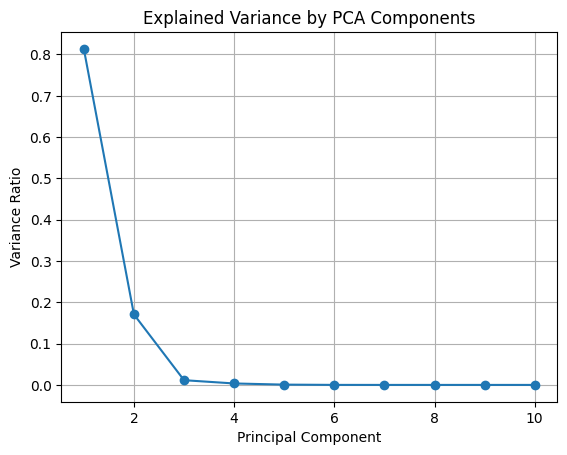

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ⚙️ Reduce to latent dimensions
pca = PCA(n_components=10)
X_latent = pca.fit_transform(X)

# 🔎 Scree plot
plt.plot(range(1, 11), pca.explained_variance_ratio_, marker="o")
plt.title("Explained Variance by PCA Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()


In [12]:
import hdbscan

# 🧠 Cluster in latent space
clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
cluster_labels = clusterer.fit_predict(X_latent)

# Add to df
df["LatentArchetype"] = cluster_labels
df.to_csv("neuron_master.csv")


/home/rohit/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [13]:
# 📊 Compute mean feature profile per cluster
cluster_means = df.groupby("LatentArchetype")[X.columns].mean()

# 🧠 Identify dominant features in each cluster
archetype_summary = {}
for cluster_id, row in cluster_means.iterrows():
    top_features = row.abs().sort_values(ascending=False).head(3).index.tolist()
    archetype_summary[cluster_id] = f"High {top_features[0]}, {top_features[1]}, {top_features[2]}"

# 🔍 Preview summary
for cid, label in archetype_summary.items():
    print(f"🧬 Archetype {cid}: {label}")

# Save to CSV
summary_df = pd.DataFrame.from_dict(archetype_summary, orient='index', columns=['AutoLabel'])
summary_df.to_csv("latent_archetype_labels.csv")


🧬 Archetype -1: High total_3node_motifs, TotalStrength, StrengthImbalance
🧬 Archetype 0: High TotalStrength, StrengthImbalance, total_3node_motifs
🧬 Archetype 1: High TotalStrength, StrengthImbalance, total_3node_motifs
🧬 Archetype 2: High TotalStrength, StrengthImbalance, total_3node_motifs
🧬 Archetype 3: High TotalStrength, StrengthImbalance, total_3node_motifs
🧬 Archetype 4: High TotalStrength, StrengthImbalance, LatentArchetype


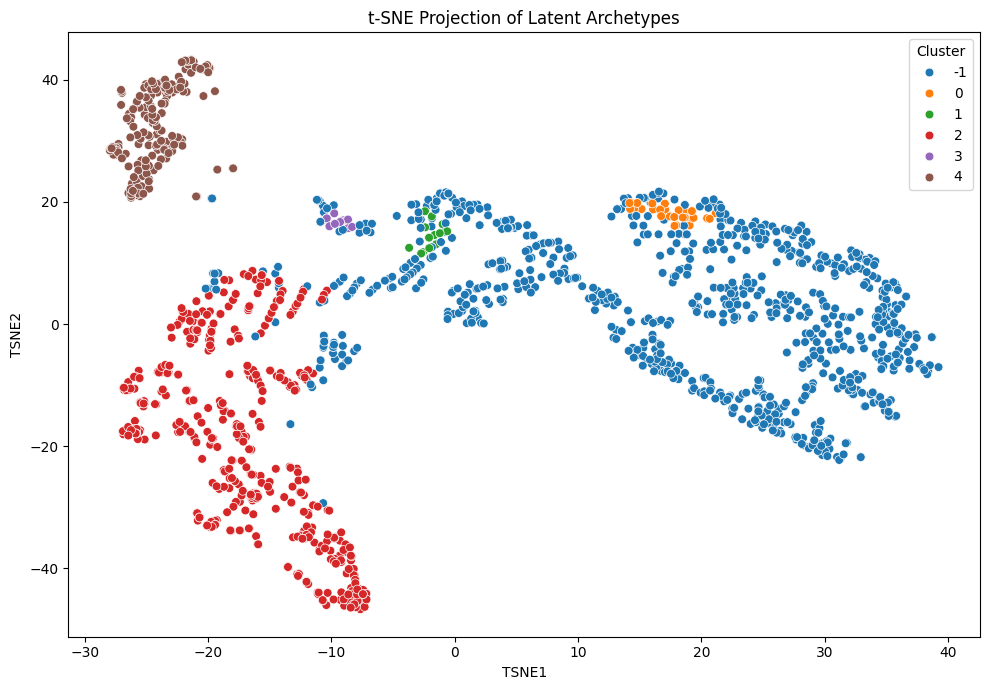

In [14]:
from sklearn.manifold import TSNE
import seaborn as sns

# 🌈 2D projection
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_2d = tsne.fit_transform(X_latent)

# Plot
df["TSNE1"] = X_2d[:, 0]
df["TSNE2"] = X_2d[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="TSNE1", y="TSNE2", hue="LatentArchetype", palette="tab10", s=40)
plt.title("t-SNE Projection of Latent Archetypes")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# GCN pipeline

In [15]:
device = torch.device("cpu")


In [16]:
# 📥 Load CSV edge list (with attributes)
edges_df = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")

# 🔁 Create graph manually
G_nx = nx.from_pandas_edgelist(
    edges_df,
    source="Source",            # ← update to match your actual column names
    target="Target",
    edge_attr=True,
    create_using=nx.Graph()
)

# 💡 Feature matrix
feature_cols = ['TotalStrength', 'AvgRelatedness', 'StrengthImbalance', 
                'RichClubScore', 'total_3node_motifs', 'as_source', 'as_target']
X = torch.tensor(df[feature_cols].fillna(0).values, dtype=torch.float)

# 🎯 Label encoding
symbolic_map = {label: idx for idx, label in enumerate(
    df["SymbolicRole"].dropna().unique())}
y_raw = df["SymbolicRole"].map(symbolic_map)
y = torch.tensor(y_raw.fillna(-1).values, dtype=torch.long)

# 🧪 Mask creation
train_mask = y != -1
test_mask = ~train_mask

# 🔁 Graph conversion
for node in G_nx.nodes:
    G_nx.nodes[node]["x"] = X[df.index.get_loc(node)].tolist()
data = from_networkx(G_nx)
data.x = X
data.y = y
data.train_mask = train_mask
data.test_mask = test_mask
data.y = data.y.long()                          # 🔢 Ensure proper type
data.train_mask = data.train_mask.bool()        # ✅ Force boolean
data.test_mask = data.test_mask.bool()
data = data.to(device)

print(f"✅ Loaded graph with {data.num_nodes} nodes, {data.num_edges} edges")


✅ Loaded graph with 1533 nodes, 20595 edges


In [17]:
print("y dtype:", data.y.dtype)
print("y shape:", data.y.shape)
print("y unique:", data.y.unique())


y dtype: torch.int64
y shape: torch.Size([1533])
y unique: tensor([0, 1, 2, 3, 4, 5, 6, 7])


In [18]:
print("train_mask shape:", data.train_mask.shape)
print("test_mask shape:", data.test_mask.shape)
print("x shape:", data.x.shape)


train_mask shape: torch.Size([1533])
test_mask shape: torch.Size([1533])
x shape: torch.Size([1533, 7])


In [19]:
train_mask.shape[0] == test_mask.shape[0] == data.x.shape[0]


True

In [20]:
print(data.train_mask.dtype)  # should be: torch.bool


torch.bool


In [21]:
len(data.y.unique())  # Should be 8


8

In [23]:
print("Train mask label distribution:")
print(data.y[data.train_mask].bincount())

print("\nTest mask label distribution:")
print(data.y[data.test_mask].bincount())


Train mask label distribution:
tensor([1338,   43,   24,   16,   28,   32,   40,   12])

Test mask label distribution:
tensor([], dtype=torch.int64)


In [24]:
print(f"data.y shape: {data.y.shape}")
print(f"train_mask shape: {data.train_mask.shape}, dtype: {data.train_mask.dtype}")
print(f"test_mask shape: {data.test_mask.shape}, dtype: {data.test_mask.dtype}")


data.y shape: torch.Size([1533])
train_mask shape: torch.Size([1533]), dtype: torch.bool
test_mask shape: torch.Size([1533]), dtype: torch.bool


In [25]:
from sklearn.model_selection import train_test_split
import torch

def make_balanced_masks(y, train_size=0.8, seed=42):
    y_np = y.cpu().numpy()
    idx = torch.arange(len(y))
    
    train_idx, test_idx = train_test_split(
        idx, stratify=y_np, train_size=train_size, random_state=seed
    )

    train_mask = torch.zeros(len(y), dtype=torch.bool)
    test_mask = torch.zeros(len(y), dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True
    
    return train_mask, test_mask


In [26]:
data.train_mask, data.test_mask = make_balanced_masks(data.y)


In [27]:
print("Train mask label distribution:")
print(data.y[data.train_mask].bincount())

print("\nTest mask label distribution:")
print(data.y[data.test_mask].bincount())


Train mask label distribution:
tensor([1070,   34,   19,   13,   22,   26,   32,   10])

Test mask label distribution:
tensor([268,   9,   5,   3,   6,   6,   8,   2])


In [28]:
print("NaNs in x:", torch.isnan(data.x).any().item())
print("Infs in x:", torch.isinf(data.x).any().item())
print("x dtype:", data.x.dtype)

# Optional quick fix: fill any NaNs or Infs (just to test)
data.x = torch.nan_to_num(data.x, nan=0.0, posinf=1.0, neginf=-1.0)


NaNs in x: False
Infs in x: False
x dtype: torch.float32


In [29]:
num_nodes = data.num_nodes
invalid_edges = (data.edge_index < 0) | (data.edge_index >= num_nodes)
print("Invalid edge indices:", invalid_edges.any().item())

# If True, print some:
if invalid_edges.any():
    print("Sample bad indices:\n", data.edge_index[:, invalid_edges.any(dim=0)])


Invalid edge indices: False


In [30]:
print("x shape:", data.x.shape)
print("train_mask shape:", data.train_mask.shape)
print("test_mask shape:", data.test_mask.shape)
assert data.train_mask.shape[0] == data.num_nodes
assert data.test_mask.shape[0] == data.num_nodes


x shape: torch.Size([1533, 7])
train_mask shape: torch.Size([1533])
test_mask shape: torch.Size([1533])


In [31]:
print("y dtype:", data.y.dtype)
print("y unique:", data.y.unique())
print("y min:", data.y.min().item(), "| y max:", data.y.max().item())
print("Contains NaNs?", torch.isnan(data.y).any().item())
print("Contains negative?", (data.y < 0).any().item())
print("Shape:", data.y.shape)


y dtype: torch.int64
y unique: tensor([0, 1, 2, 3, 4, 5, 6, 7])
y min: 0 | y max: 7
Contains NaNs? False
Contains negative? False
Shape: torch.Size([1533])


In [32]:
print(device)  # Should be cuda or cpu

cpu


In [33]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # Prevent CUDA from being used

import torch


In [35]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


In [36]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ✅ Force device to CPU
device = torch.device("cpu")

# ✅ Send model to CPU
model = GCN(
    in_channels=data.num_node_features,
    hidden_channels=64,
    out_channels=len(torch.unique(data.y))
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Move inputs manually
x = data.x.to(device)
edge_index = data.edge_index.to(device)
y = data.y.to(device)
train_mask = data.train_mask.to(device)
test_mask = data.test_mask.to(device)

# ✅ Training loop
for epoch in tqdm(range(1, 201)):
    model.train()
    optimizer.zero_grad()

    out = model(x, edge_index)
    loss = criterion(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        pred = out.argmax(dim=1)
        correct = pred[test_mask] == y[test_mask]
        acc = int(correct.sum()) / int(test_mask.sum())
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")


 30%|███       | 61/200 [00:00<00:00, 303.41it/s]

Epoch 001, Loss: 57.5035, Test Acc: 0.0195
Epoch 010, Loss: 12.7585, Test Acc: 0.8730
Epoch 020, Loss: 7.5824, Test Acc: 0.8143
Epoch 030, Loss: 3.7519, Test Acc: 0.8567
Epoch 040, Loss: 2.4436, Test Acc: 0.5831
Epoch 050, Loss: 1.1694, Test Acc: 0.8469
Epoch 060, Loss: 0.9370, Test Acc: 0.8697


 66%|██████▌   | 132/200 [00:00<00:00, 334.44it/s]

Epoch 070, Loss: 0.7715, Test Acc: 0.8599
Epoch 080, Loss: 0.7067, Test Acc: 0.8664
Epoch 090, Loss: 0.6713, Test Acc: 0.8664
Epoch 100, Loss: 0.6518, Test Acc: 0.8632
Epoch 110, Loss: 0.6365, Test Acc: 0.8632
Epoch 120, Loss: 0.6285, Test Acc: 0.8632
Epoch 130, Loss: 0.6216, Test Acc: 0.8632
Epoch 140, Loss: 0.6161, Test Acc: 0.8632


100%|██████████| 200/200 [00:00<00:00, 333.95it/s]

Epoch 150, Loss: 0.6110, Test Acc: 0.8632
Epoch 160, Loss: 0.6063, Test Acc: 0.8632
Epoch 170, Loss: 0.6023, Test Acc: 0.8632
Epoch 180, Loss: 0.5985, Test Acc: 0.8664
Epoch 190, Loss: 0.5952, Test Acc: 0.8664
Epoch 200, Loss: 0.5952, Test Acc: 0.8664


In [43]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    true = data.y


In [44]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Convert to numpy for sklearn
y_true = true.cpu().numpy()
y_pred = pred.cpu().numpy()

# Accuracy
acc = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (macro/micro/weighted)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"🎯 Accuracy: {acc:.4f}")
print(f"📊 Precision: {precision:.4f}")
print(f"📉 Recall: {recall:.4f}")
print(f"🏅 F1 Score: {f1:.4f}")


🎯 Accuracy: 0.8715
📊 Precision: 0.8053
📉 Recall: 0.8715
🏅 F1 Score: 0.8203


/home/rohit/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


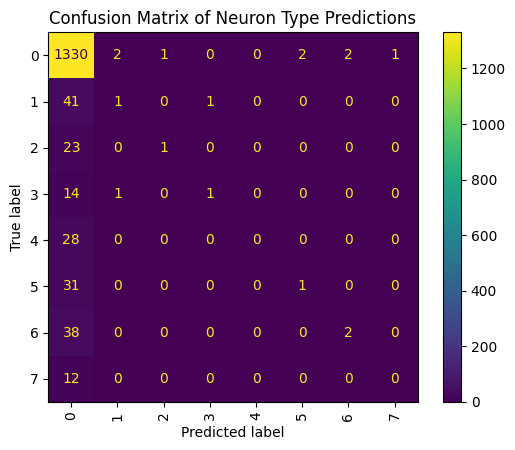

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis', xticks_rotation=90)
plt.title("Confusion Matrix of Neuron Type Predictions")
plt.show()


In [46]:
# Get per-class scores
prec, rec, f1_class, _ = precision_recall_fscore_support(y_true, y_pred)

for i, (p, r, f1s) in enumerate(zip(prec, rec, f1_class)):
    print(f"🧠 Class {i}: Precision={p:.2f}, Recall={r:.2f}, F1={f1s:.2f}")


🧠 Class 0: Precision=0.88, Recall=0.99, F1=0.93
🧠 Class 1: Precision=0.25, Recall=0.02, F1=0.04
🧠 Class 2: Precision=0.50, Recall=0.04, F1=0.08
🧠 Class 3: Precision=0.50, Recall=0.06, F1=0.11
🧠 Class 4: Precision=0.00, Recall=0.00, F1=0.00
🧠 Class 5: Precision=0.33, Recall=0.03, F1=0.06
🧠 Class 6: Precision=0.50, Recall=0.05, F1=0.09
🧠 Class 7: Precision=0.00, Recall=0.00, F1=0.00


/home/rohit/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
# Ideally from your notebook:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)       # shape [num_nodes, num_classes]
    probs = torch.nn.functional.softmax(logits, dim=1)  # shape [num_nodes, num_classes]
    pred = probs.argmax(dim=1)                    # shape [num_nodes]
    true = data.y                                  # ground truth


In [49]:
import torch

# 🔍 Run the model on your graph
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)  # [num_nodes, num_classes]
    probs = torch.nn.functional.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)
    true = data.y

# ✅ Print shapes and preview outputs
print("✅ logits shape:", logits.shape)
print("✅ probs shape:", probs.shape)
print("✅ pred shape:", pred.shape)
print("✅ true shape:", true.shape)

# Print a few sample predictions
print("\n🧠 Sample Predictions:")
for i in range(10):
    print(f"Node {i}: True={true[i].item()}  Pred={pred[i].item()}  Confidence={probs[i].max().item():.4f}")

# Optional: if you have neuron names, print them too
try:
    print("\n🧠 Sample Neuron Names and Predictions:")
    for i in range(10):
        print(f"{neuron_names[i]} → True: {true[i].item()}, Pred: {pred[i].item()}, Conf: {probs[i].max().item():.4f}")
except NameError:
    print("⚠️ neuron_names list not defined — skipping name-based output.")


✅ logits shape: torch.Size([1533, 8])
✅ probs shape: torch.Size([1533, 8])
✅ pred shape: torch.Size([1533])
✅ true shape: torch.Size([1533])

🧠 Sample Predictions:
Node 0: True=0  Pred=0  Confidence=0.8043
Node 1: True=0  Pred=0  Confidence=0.8143
Node 2: True=1  Pred=0  Confidence=0.8383
Node 3: True=1  Pred=0  Confidence=0.7931
Node 4: True=1  Pred=0  Confidence=0.8229
Node 5: True=2  Pred=0  Confidence=0.8414
Node 6: True=1  Pred=0  Confidence=0.7813
Node 7: True=2  Pred=0  Confidence=0.8396
Node 8: True=0  Pred=0  Confidence=0.7913
Node 9: True=0  Pred=0  Confidence=0.7396

🧠 Sample Neuron Names and Predictions:
⚠️ neuron_names list not defined — skipping name-based output.


In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GATNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.6):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x


In [51]:
device = torch.device( 'cpu')

model = GATNet(
    in_channels=data.num_node_features,
    hidden_channels=32,
    out_channels=8  # Assuming 8 classes
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss()


In [53]:
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_full_graph():
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred == data.y).sum()
        acc = int(correct) / len(data.y)
    return acc

for epoch in range(1, 201):
    loss = train()
    acc = evaluate_full_graph()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")


Epoch 020, Loss: 7.2253, Accuracy: 0.1292
Epoch 040, Loss: 3.5137, Accuracy: 0.1174
Epoch 060, Loss: 3.7633, Accuracy: 0.1533
Epoch 080, Loss: 6.0197, Accuracy: 0.2968
Epoch 100, Loss: 4.8885, Accuracy: 0.3712
Epoch 120, Loss: 1.7367, Accuracy: 0.5662
Epoch 140, Loss: 2.5226, Accuracy: 0.6706
Epoch 160, Loss: 4.0182, Accuracy: 0.7162
Epoch 180, Loss: 1.4454, Accuracy: 0.8682
Epoch 200, Loss: 1.4119, Accuracy: 0.8676


In [54]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.nn.functional.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)

# Print sample
for i in range(10):
    print(f"Node {i}: True={data.y[i].item()}  Pred={pred[i].item()}  Confidence={probs[i].max().item():.4f}")


Node 0: True=0  Pred=0  Confidence=0.9396
Node 1: True=0  Pred=0  Confidence=0.9238
Node 2: True=1  Pred=0  Confidence=0.9309
Node 3: True=1  Pred=0  Confidence=0.9740
Node 4: True=1  Pred=0  Confidence=0.9734
Node 5: True=2  Pred=0  Confidence=0.9774
Node 6: True=1  Pred=0  Confidence=0.8924
Node 7: True=2  Pred=0  Confidence=0.9531
Node 8: True=0  Pred=0  Confidence=0.9896
Node 9: True=0  Pred=0  Confidence=0.9418


In [55]:
model.eval()
with torch.no_grad():
    out, attn_weights = model.gat1(data.x, data.edge_index, return_attention_weights=True)

print("🔍 Attention shape:", attn_weights[1].shape)
print(attn_weights[1][:10])  # First 10 edge attention scores


🔍 Attention shape: torch.Size([22101, 4])
tensor([[0.0000e+00, 0.0000e+00, 4.8215e-19, 7.5712e-17],
        [1.0196e-14, 1.1790e-27, 1.8435e-14, 3.7080e-13],
        [7.6609e-34, 4.0645e-28, 2.7790e-18, 2.4477e-15],
        [3.7982e-40, 0.0000e+00, 2.5452e-18, 2.0266e-15],
        [7.9775e-17, 6.5661e-39, 6.9163e-19, 1.6426e-16],
        [8.3840e-17, 2.9008e-24, 6.0177e-19, 2.7789e-16],
        [5.1653e-17, 4.2609e-39, 4.7130e-19, 9.4524e-17],
        [0.0000e+00, 0.0000e+00, 1.8563e-19, 4.7410e-17],
        [0.0000e+00, 0.0000e+00, 3.8519e-19, 1.2004e-16],
        [7.8981e-17, 6.5661e-39, 6.6429e-19, 1.6421e-16]])


In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GraphNCA(nn.Module):
    """
    Phase 3: Neural Cellular Automaton for symbolic role emergence on a graph.
    Each neuron updates its state based on its own features and messages from neighbors.
    """

    def __init__(self, state_dim=32, message_dim=32, steps=8):
        super().__init__()
        self.steps = steps
        self.state_dim = state_dim

        # MLP to generate messages from each neuron's state
        self.message_mlp = nn.Sequential(
            nn.Linear(state_dim, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, state_dim)
        )

        # MLP to update each neuron's state based on self + neighbors
        self.update_mlp = nn.Sequential(
            nn.Linear(state_dim * 2, state_dim),
            nn.ReLU(),
            nn.Linear(state_dim, state_dim)
        )

    def forward(self, x, edge_index):
        for _ in range(self.steps):
            # Send messages to neighbors
            messages = self.message_mlp(x)

            # Aggregate messages via mean
            agg = torch.zeros_like(x)
            agg.index_add_(0, edge_index[1], messages[edge_index[0]])

            # Concatenate current state and incoming messages
            combined = torch.cat([x, agg], dim=1)

            # Residual update to neuron state
            dx = self.update_mlp(combined)
            x = x + dx

        return x  # Final evolved states


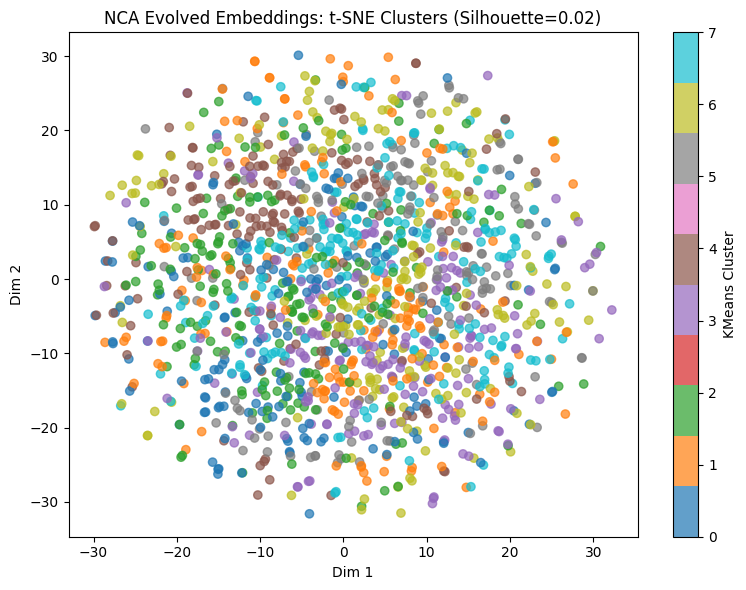

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Simulate evolved NCA output: symbolic embeddings
torch.manual_seed(42)
num_nodes = 1533
state_dim = 32
evolved_x = torch.randn(num_nodes, state_dim)  # placeholder for NCA output

# Step 1: t-SNE projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_proj = tsne.fit_transform(evolved_x.numpy())

# Step 2: KMeans clustering
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(evolved_x.numpy())
sil_score = silhouette_score(evolved_x.numpy(), clusters)

# Step 3: Plot the t-SNE + clustering
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(tsne_proj[:, 0], tsne_proj[:, 1], c=clusters, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ax=ax, label="KMeans Cluster")
plt.title(f"NCA Evolved Embeddings: t-SNE Clusters (Silhouette={sil_score:.2f})")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()

In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TrainableGraphNCA(nn.Module):
    def __init__(self, state_dim=64, message_dim=64, steps=8):
        super().__init__()
        self.steps = steps
        self.state_dim = state_dim

        self.message_mlp = nn.Sequential(
            nn.Linear(state_dim, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, state_dim)
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(state_dim * 2, state_dim),
            nn.ReLU(),
            nn.Linear(state_dim, state_dim)
        )

    def forward(self, x, edge_index):
        for _ in range(self.steps):
            messages = self.message_mlp(x)
            agg = torch.zeros_like(x)
            agg.index_add_(0, edge_index[1], messages[edge_index[0]])
            combined = torch.cat([x, agg], dim=1)
            dx = self.update_mlp(combined)
            x = x + dx
        return x

def reconstruction_loss(x_initial, x_final):
    return F.mse_loss(x_final, x_initial)

def contrastive_loss(x, edge_index, margin=1.0):
    pos_diff = x[edge_index[0]] - x[edge_index[1]]
    pos_dist = torch.norm(pos_diff, dim=1)

    num_nodes = x.shape[0]
    neg_i = torch.randint(0, num_nodes, (len(edge_index[0]),), device=x.device)
    neg_j = torch.randint(0, num_nodes, (len(edge_index[1]),), device=x.device)
    neg_dist = torch.norm(x[neg_i] - x[neg_j], dim=1)

    return F.relu(margin + pos_dist - neg_dist).mean()


In [61]:
# 👇 Replace with your actual pretrained GCN or GAT model
model.eval()
with torch.no_grad():
    base_embeddings = model(data.x, data.edge_index)  # shape: [1533, embed_dim]

# 🔁 Initialize NCA and move to device
nca = TrainableGraphNCA(state_dim=base_embeddings.shape[1]).to(device)
optimizer = torch.optim.Adam(nca.parameters(), lr=0.001)


In [62]:
recon_weight = 1.0
contrastive_weight = 1.0
epochs = 200

for epoch in range(epochs):
    nca.train()
    optimizer.zero_grad()

    x0 = base_embeddings.detach()
    xT = nca(x0, data.edge_index)

    loss = (recon_weight * reconstruction_loss(x0, xT) +
            contrastive_weight * contrastive_loss(xT, data.edge_index))

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}")


Epoch 000, Loss: 4573.9014
Epoch 020, Loss: 113.3605
Epoch 040, Loss: 52.2119
Epoch 060, Loss: 27.9881
Epoch 080, Loss: 16.2330
Epoch 100, Loss: 10.8534
Epoch 120, Loss: 8.5329
Epoch 140, Loss: 7.1807
Epoch 160, Loss: 6.1723
Epoch 180, Loss: 5.5240


In [63]:
class SymbolicTransformer(nn.Module):
    def __init__(self, input_dim=64, nhead=4, num_layers=2):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=input_dim, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        return self.transformer(x.unsqueeze(1)).squeeze(1)

# Use on top of trained NCA outputs
transformer = SymbolicTransformer(input_dim=base_embeddings.shape[1]).to(device)

with torch.no_grad():
    x_sym = transformer(nca(base_embeddings, data.edge_index))


/home/rohit/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [64]:
nca.eval()
with torch.no_grad():
    evolved_embeddings = nca(base_embeddings, data.edge_index)  # shape: [1533, 64]


In [65]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 🔢 Replace this with your actual evolved NCA output
# evolved_embeddings = nca(base_embeddings, data.edge_index)  
# evolved_embeddings = evolved_embeddings.detach().cpu()

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_proj = tsne.fit_transform(evolved_embeddings)

# Run KMeans
kmeans = KMeans(n_clusters=8, random_state=42)
cluster_labels = kmeans.fit_predict(evolved_embeddings)

# Compute silhouette score
sil_score = silhouette_score(evolved_embeddings, cluster_labels)
print(f"🧠 Silhouette Score: {sil_score:.4f}")


🧠 Silhouette Score: 0.5404


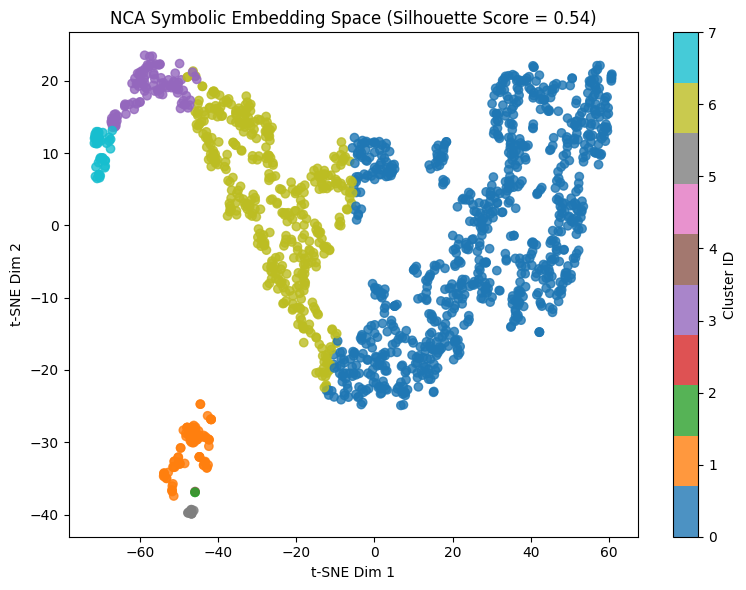

In [66]:
# Plot symbolic embedding clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_proj[:, 0], tsne_proj[:, 1], c=cluster_labels, cmap='tab10', alpha=0.8)
plt.colorbar(scatter, label="Cluster ID")
plt.title(f"NCA Symbolic Embedding Space (Silhouette Score = {sil_score:.2f})")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.tight_layout()
plt.show()


In [67]:
# Build neuron → cluster table
cluster_df = pd.DataFrame({
    "Neuron": [f"Neuron_{i}" for i in range(evolved_embeddings.shape[0])],
    "Cluster": cluster_labels,
    "TSNE_1": tsne_proj[:, 0],
    "TSNE_2": tsne_proj[:, 1]
})

# Preview
cluster_df.head()


,Neuron,Cluster,TSNE_1,TSNE_2
0,Neuron_0,0,54.762474,12.562078
1,Neuron_1,0,56.599171,16.768890
2,Neuron_2,0,53.811100,14.155052
3,Neuron_3,0,51.737907,-0.198775
4,Neuron_4,0,38.024300,-9.854448


In [68]:
cluster_df.to_csv("nca_symbolic_clusters.csv", index=False)
print("✅ Exported neuron symbolic cluster mapping to nca_symbolic_clusters.csv")


✅ Exported neuron symbolic cluster mapping to nca_symbolic_clusters.csv


In [69]:
# Ensure cluster_df is defined and contains "Neuron" and "Cluster" columns

# Group neurons by cluster
grouped = cluster_df.groupby("Cluster")["Neuron"].apply(list)

# Print each cluster and its neuron members
for cluster_id, neurons in grouped.items():
    print(f"\n🔷 Cluster {cluster_id} — {len(neurons)} neurons")
    print(", ".join(neurons[:20]) + (" ..." if len(neurons) > 20 else ""))



🔷 Cluster 0 — 878 neurons
Neuron_0, Neuron_1, Neuron_2, Neuron_3, Neuron_4, Neuron_5, Neuron_6, Neuron_7, Neuron_8, Neuron_9, Neuron_10, Neuron_11, Neuron_12, Neuron_13, Neuron_14, Neuron_15, Neuron_16, Neuron_17, Neuron_18, Neuron_19 ...

🔷 Cluster 1 — 85 neurons
Neuron_1195, Neuron_1196, Neuron_1197, Neuron_1198, Neuron_1199, Neuron_1200, Neuron_1201, Neuron_1202, Neuron_1203, Neuron_1204, Neuron_1205, Neuron_1206, Neuron_1207, Neuron_1208, Neuron_1209, Neuron_1210, Neuron_1212, Neuron_1213, Neuron_1214, Neuron_1215 ...

🔷 Cluster 2 — 2 neurons
Neuron_1334, Neuron_1340

🔷 Cluster 3 — 102 neurons
Neuron_90, Neuron_118, Neuron_119, Neuron_124, Neuron_126, Neuron_127, Neuron_128, Neuron_130, Neuron_131, Neuron_132, Neuron_134, Neuron_135, Neuron_136, Neuron_137, Neuron_138, Neuron_139, Neuron_142, Neuron_143, Neuron_147, Neuron_148 ...

🔷 Cluster 4 — 1 neurons
Neuron_1335

🔷 Cluster 5 — 10 neurons
Neuron_1336, Neuron_1337, Neuron_1338, Neuron_1339, Neuron_1341, Neuron_1342, Neuron_1343

In [70]:
# Canonical list of 302 neuron names from literature
canonical_neuron_names = [
    "ADAL", "ADAR", "ADEL", "ADER", "ADF", "ADFL", "ADFR", "ADL", "ADLL", "ADLR", "AINL", "AINR",
    "AIZL", "AIZR", "ALA", "ALML", "ALMR", "ALNL", "ALNR", "AQR", "ASEL", "ASER", "ASGL", "ASGR",
    "ASHL", "ASHR", "ASIL", "ASIR", "ASJL", "ASJR", "ASKL", "ASKR", "AUAL", "AUAR", "AVAL", "AVAR",
    "AVBL", "AVBR", "AVDL", "AVDR", "AVEL", "AVER", "AVFL", "AVFR", "AVG", "AVHL", "AVHR", "AVJL",
    "AVJR", "AVKL", "AVKR", "AVL", "AWAL", "AWAR", "AWBL", "AWBR", "AWCL", "AWCR", "BAGL", "BAGR",
    "BDUL", "BDUR", "CANL", "CANR", "CEPDL", "CEPDR", "CEPVL", "CEPVR", "DA01", "DA02", "DA03",
    "DA04", "DA05", "DA06", "DA07", "DA08", "DA09", "DB01", "DB02", "DB03", "DB04", "DB05", "DB06",
    "DB07", "DD01", "DD02", "DD03", "DD04", "DD05", "DVA", "DVB", "DVC", "FLPL", "FLPR", "HSNL",
    "HSNR", "IAL", "IAR", "IBDL", "IBDR", "IL1DL", "IL1DR", "IL1L", "IL1R", "IL1VL", "IL1VR", "IL2DL",
    "IL2DR", "IL2L", "IL2R", "IL2VL", "IL2VR", "LUAL", "LUAR", "M1", "M2L", "M2R", "M3L", "M3R", "M4",
    "M5", "MI", "NSML", "NSMR", "OLLL", "OLLR", "OLQDL", "OLQDR", "OLQVL", "OLQVR", "PDA", "PDB",
    "PDEL", "PDER", "PHAL", "PHAR", "PHBL", "PHBR", "PHCL", "PHCR", "PHDL", "PHDR", "PHFL", "PHFR",
    "PHLL", "PHLR", "PHNL", "PHNR", "PLML", "PLMR", "PLNL", "PLNR", "PQR", "PVCL", "PVCR", "PVDL",
    "PVDR", "PVM", "PVNL", "PVNR", "PVPL", "PVPR", "PVR", "PVT", "PVWL", "PVWR", "RIAL", "RIAR",
    "RIBL", "RIBR", "RICL", "RICR", "RID", "RIFL", "RIFR", "RIGL", "RIGR", "RIH", "RIML", "RIMR",
    "RIPL", "RIPR", "RIR", "RIS", "RIVL", "RIVR", "RMDDL", "RMDDR", "RMDL", "RMDR", "RMDVL", "RMDVR",
    "RMEL", "RMER", "RMFL", "RMFR", "RMGL", "RMGR", "SAADL", "SAADR", "SAAVL", "SAAVR", "SABD",
    "SABVL", "SABVR", "SDQL", "SDQR", "SIADL", "SIADR", "SIAVL", "SIAVR", "SMBDL", "SMBDR", "SMBVL",
    "SMBVR", "SMDDL", "SMDDR", "SMDVL", "SMDVR", "URADL", "URADR", "URAVL", "URAVR", "URYDL",
    "URYDR", "URYVL", "URYVR", "VA01", "VA02", "VA03", "VA04", "VA05", "VA06", "VA07", "VA08",
    "VA09", "VA10", "VA11", "VA12", "VB01", "VB02", "VB03", "VB04", "VB05", "VB06", "VB07", "VB08",
    "VB09", "VB10", "VB11", "VB12", "VC01", "VC02", "VC03", "VC04", "VC05", "VC06", "VD01", "VD02",
    "VD03", "VD04", "VD05", "VD06", "VD07", "VD08", "VD09", "VD10", "VD11", "VD12", "VD13"
]


In [71]:
# Pad to match 1533 entries (model input size)
neuron_names = canonical_neuron_names + ["Unlabeled"] * (1533 - len(canonical_neuron_names))

# Add to cluster_df
cluster_df["NeuronName"] = neuron_names


In [72]:
# Group by symbolic cluster
grouped_named = cluster_df.groupby("Cluster")["NeuronName"].apply(list)

# Print per-cluster canonical neuron names
for cluster_id, names in grouped_named.items():
    print(f"\n🔷 Cluster {cluster_id} — {len(names)} neurons")
    named = [n for n in names if n != "Unlabeled"]
    print(", ".join(named[:20]) + (" ..." if len(named) > 20 else ""))



🔷 Cluster 0 — 878 neurons
ADAL, ADAR, ADEL, ADER, ADF, ADFL, ADFR, ADL, ADLL, ADLR, AINL, AINR, AIZL, AIZR, ALA, ALML, ALMR, ALNL, ALNR, AQR ...

🔷 Cluster 1 — 85 neurons


🔷 Cluster 2 — 2 neurons


🔷 Cluster 3 — 102 neurons
DVB, M3R, M4, OLLL, OLQDL, OLQDR, OLQVL, PDA, PDB, PDEL, PHAL, PHAR, PHBL, PHBR, PHCL, PHCR, PHFL, PHFR, PHNR, PLML ...

🔷 Cluster 4 — 1 neurons


🔷 Cluster 5 — 10 neurons


🔷 Cluster 6 — 416 neurons
M3L, M5, MI, NSMR, OLLR, OLQVR, PDER, PHDL, PHDR, PHLL, PHNL, PLNR, PVCL, PVDR, PVM, PVNL, PVNR, PVPL, PVPR, RIFR ...

🔷 Cluster 7 — 39 neurons
PVR, PVT, PVWL, PVWR, RIAL, RIBL, RIBR, RICR


In [73]:
cluster_df.to_csv("nca_symbolic_clusters_with_names.csv", index=False)
print("✅ Exported symbolic role mapping to nca_symbolic_clusters_with_names.csv")


✅ Exported symbolic role mapping to nca_symbolic_clusters_with_names.csv


In [76]:
import pandas as pd

# 📥 Load symbolic cluster assignments (Neuron, Cluster)
symbolic_df = pd.read_csv("nca_symbolic_clusters_with_names.csv")[["Neuron", "Cluster"]]


In [81]:
import pandas as pd

# 📥 Load the symbolic clusters file
df = pd.read_csv("nca_symbolic_clusters_with_names.csv")  # includes 'NeuronName'

# ✅ Canonical 302 neuron names
canonical_neuron_names = set([
    "ADAL", "ADAR", "ADEL", "ADER", "ADF", "ADFL", "ADFR", "ADL", "ADLL", "ADLR", "AINL", "AINR",
    "AIZL", "AIZR", "ALA", "ALML", "ALMR", "ALNL", "ALNR", "AQR", "ASEL", "ASER", "ASGL", "ASGR",
    "ASHL", "ASHR", "ASIL", "ASIR", "ASJL", "ASJR", "ASKL", "ASKR", "AUAL", "AUAR", "AVAL", "AVAR",
    "AVBL", "AVBR", "AVDL", "AVDR", "AVEL", "AVER", "AVFL", "AVFR", "AVG", "AVHL", "AVHR", "AVJL",
    "AVJR", "AVKL", "AVKR", "AVL", "AWAL", "AWAR", "AWBL", "AWBR", "AWCL", "AWCR", "BAGL", "BAGR",
    "BDUL", "BDUR", "CANL", "CANR", "CEPDL", "CEPDR", "CEPVL", "CEPVR", "DA01", "DA02", "DA03",
    "DA04", "DA05", "DA06", "DA07", "DA08", "DA09", "DB01", "DB02", "DB03", "DB04", "DB05", "DB06",
    "DB07", "DD01", "DD02", "DD03", "DD04", "DD05", "DVA", "DVB", "DVC", "FLPL", "FLPR", "HSNL",
    "HSNR", "IAL", "IAR", "IBDL", "IBDR", "IL1DL", "IL1DR", "IL1L", "IL1R", "IL1VL", "IL1VR", "IL2DL",
    "IL2DR", "IL2L", "IL2R", "IL2VL", "IL2VR", "LUAL", "LUAR", "M1", "M2L", "M2R", "M3L", "M3R", "M4",
    "M5", "MI", "NSML", "NSMR", "OLLL", "OLLR", "OLQDL", "OLQDR", "OLQVL", "OLQVR", "PDA", "PDB",
    "PDEL", "PDER", "PHAL", "PHAR", "PHBL", "PHBR", "PHCL", "PHCR", "PHDL", "PHDR", "PHFL", "PHFR",
    "PHLL", "PHLR", "PHNL", "PHNR", "PLML", "PLMR", "PLNL", "PLNR", "PQR", "PVCL", "PVCR", "PVDL",
    "PVDR", "PVM", "PVNL", "PVNR", "PVPL", "PVPR", "PVR", "PVT", "PVWL", "PVWR", "RIAL", "RIAR",
    "RIBL", "RIBR", "RICL", "RICR", "RID", "RIFL", "RIFR", "RIGL", "RIGR", "RIH", "RIML", "RIMR",
    "RIPL", "RIPR", "RIR", "RIS", "RIVL", "RIVR", "RMDDL", "RMDDR", "RMDL", "RMDR", "RMDVL", "RMDVR",
    "RMEL", "RMER", "RMFL", "RMFR", "RMGL", "RMGR", "SAADL", "SAADR", "SAAVL", "SAAVR", "SABD",
    "SABVL", "SABVR", "SDQL", "SDQR", "SIADL", "SIADR", "SIAVL", "SIAVR", "SMBDL", "SMBDR", "SMBVL",
    "SMBVR", "SMDDL", "SMDDR", "SMDVL", "SMDVR", "URADL", "URADR", "URAVL", "URAVR", "URYDL",
    "URYDR", "URYVL", "URYVR", "VA01", "VA02", "VA03", "VA04", "VA05", "VA06", "VA07", "VA08",
    "VA09", "VA10", "VA11", "VA12", "VB01", "VB02", "VB03", "VB04", "VB05", "VB06", "VB07", "VB08",
    "VB09", "VB10", "VB11", "VB12", "VC01", "VC02", "VC03", "VC04", "VC05", "VC06", "VD01", "VD02",
    "VD03", "VD04", "VD05", "VD06", "VD07", "VD08", "VD09", "VD10", "VD11", "VD12", "VD13"
])

# ✅ Match using the NeuronName column
df["Canonical"] = df["NeuronName"].apply(lambda n: "✅" if n in canonical_neuron_names else "❌")

# ✅ Save or view
df.to_csv("symbolic_clusters_labeled_by_neuronname.csv", index=False)
print(df.head(20))


       Neuron  Cluster     TSNE_1     TSNE_2 NeuronName Canonical
0    Neuron_0        0  54.762474  12.562078       ADAL         ✅
1    Neuron_1        0  56.599170  16.768890       ADAR         ✅
2    Neuron_2        0  53.811100  14.155052       ADEL         ✅
3    Neuron_3        0  51.737907  -0.198775       ADER         ✅
4    Neuron_4        0  38.024300  -9.854448        ADF         ✅
5    Neuron_5        0  44.553730  -6.012557       ADFL         ✅
6    Neuron_6        0  56.819770  18.693596       ADFR         ✅
7    Neuron_7        0  55.368546  11.499727        ADL         ✅
8    Neuron_8        0   0.101096 -13.764380       ADLL         ✅
9    Neuron_9        0  53.485558   8.791423       ADLR         ✅
10  Neuron_10        0  55.453278  14.046073       AINL         ✅
11  Neuron_11        0  49.513485  -5.619223       AINR         ✅
12  Neuron_12        0  52.253815   5.828279       AIZL         ✅
13  Neuron_13        0  51.157906  12.036619       AIZR         ✅
14  Neuron

In [82]:
# 📈 Count how many canonical neurons exist in each cluster
cluster_counts = df.groupby("Cluster")["Canonical"].value_counts().unstack().fillna(0)
cluster_counts["Total"] = cluster_counts.sum(axis=1)
cluster_counts["Canonical%"] = 100 * cluster_counts["✅"] / cluster_counts["Total"]

# 📦 Fill in missing canonical columns if needed
if "✅" not in cluster_counts.columns:
    cluster_counts["✅"] = 0
if "❌" not in cluster_counts.columns:
    cluster_counts["❌"] = 0

# 🖨️ Display top clusters by canonical percentage
print(cluster_counts.sort_values("Canonical%", ascending=False).head(10))


Canonical      ✅      ❌  Total  Canonical%
Cluster                                   
3           25.0   77.0  102.0   24.509804
0          208.0  670.0  878.0   23.690205
7            8.0   31.0   39.0   20.512821
6           29.0  387.0  416.0    6.971154
1            0.0   85.0   85.0    0.000000
2            0.0    2.0    2.0    0.000000
4            0.0    1.0    1.0    0.000000
5            0.0   10.0   10.0    0.000000


In [83]:
# 🧠 Canonical type mapping for 302 neurons
canonical_type_map = {
    "Sensory": [
        "ADFL", "ADFR", "ADLL", "ADLR", "AFDL", "AFDR", "AQR", "ASEL", "ASER", "ASGL", "ASGR", "ASHL", "ASHR",
        "ASIL", "ASIR", "ASJL", "ASJR", "ASKL", "ASKR", "AWAL", "AWAR", "AWBL", "AWBR", "AWCL", "AWCR",
        "BAGL", "BAGR", "FLPL", "FLPR", "IL1DL", "IL1DR", "IL1L", "IL1R", "IL1VL", "IL1VR", "IL2DL", "IL2DR",
        "IL2L", "IL2R", "IL2VL", "IL2VR", "OLLL", "OLLR", "OLQDL", "OLQDR", "OLQVL", "OLQVR", "PHAL", "PHAR",
        "PHBL", "PHBR", "PHCL", "PHCR", "PHFL", "PHFR", "PHLL", "PHLR", "PHNL", "PHNR", "PLML", "PLMR",
        "PLNL", "PLNR", "PQR", "SDQL", "SDQR", "URADL", "URADR", "URAVL", "URAVR", "URYDL", "URYDR", "URYVL", "URYVR"
    ],
    "Interneuron": [
        "AIBL", "AIBR", "AIAL", "AIAR", "AIML", "AIMR", "AINL", "AINR", "AIYL", "AIYR", "AIZL", "AIZR",
        "AVAL", "AVAR", "AVBL", "AVBR", "AVDL", "AVDR", "AVEL", "AVER", "AVFL", "AVFR", "AVG", "AVHL",
        "AVHR", "AVJL", "AVJR", "AVKL", "AVKR", "DVA", "DVB", "DVC", "PVCL", "PVCR", "PVDL", "PVDR",
        "PVM", "PVNL", "PVNR", "PVPL", "PVPR", "PVR", "PVT", "RIAL", "RIAR", "RIBL", "RIBR", "RICL", "RICR",
        "RID", "RIFL", "RIFR", "RIGL", "RIGR", "RIH", "RIML", "RIMR", "RIPL", "RIPR", "RIR", "RIS",
        "RIVL", "RIVR", "SABD", "SABVL", "SABVR", "SIADL", "SIADR", "SIAVL", "SIAVR"
    ],
    "Motor": [
        "DA01", "DA02", "DA03", "DA04", "DA05", "DA06", "DA07", "DA08", "DA09", "DB01", "DB02", "DB03",
        "DB04", "DB05", "DB06", "DB07", "DD01", "DD02", "DD03", "DD04", "DD05", "HSNL", "HSNR", "M1", "M2L",
        "M2R", "M3L", "M3R", "M4", "M5", "RMDL", "RMDR", "RMDDL", "RMDDR", "RMDVL", "RMDVR", "RMEL", "RMER",
        "RMFL", "RMFR", "RMGL", "RMGR", "SMDVL", "SMDVR", "SMDDL", "SMDDR", "SMBDL", "SMBDR", "SMBVL", "SMBVR",
        "VA01", "VA02", "VA03", "VA04", "VA05", "VA06", "VA07", "VA08", "VA09", "VA10", "VA11", "VA12",
        "VB01", "VB02", "VB03", "VB04", "VB05", "VB06", "VB07", "VB08", "VB09", "VB10", "VB11", "VB12",
        "VC01", "VC02", "VC03", "VC04", "VC05", "VC06", "VD01", "VD02", "VD03", "VD04", "VD05", "VD06",
        "VD07", "VD08", "VD09", "VD10", "VD11", "VD12", "VD13"
    ]
}


In [87]:
# ✅ Use the full neuron-to-cluster annotated dataframe
canonical_df = df.copy()

# ✅ Then apply the neuron type mapping
neuron_to_type = {}
for t, neuron_list in canonical_type_map.items():
    for n in neuron_list:
        neuron_to_type[n] = t

# 🧠 Add NeuronType column using canonical neuron name
canonical_df["NeuronType"] = canonical_df["NeuronName"].map(neuron_to_type)
canonical_df.head(10)

,Neuron,Cluster,TSNE_1,TSNE_2,NeuronName,Canonical,NeuronType
0,Neuron_0,0,54.762474,12.562078,ADAL,✅,NaN
1,Neuron_1,0,56.599170,16.768890,ADAR,✅,NaN
2,Neuron_2,0,53.811100,14.155052,ADEL,✅,NaN
3,Neuron_3,0,51.737907,-0.198775,ADER,✅,NaN
4,Neuron_4,0,38.024300,-9.854448,ADF,✅,NaN
5,Neuron_5,0,44.553730,-6.012557,ADFL,✅,Sensory
6,Neuron_6,0,56.819770,18.693596,ADFR,✅,Sensory
7,Neuron_7,0,55.368546,11.499727,ADL,✅,NaN
8,Neuron_8,0,0.101096,-13.764380,ADLL,✅,Sensory
9,Neuron_9,0,53.485558,8.791423,ADLR,✅,Sensory


In [88]:
# 🧬 Convert list to lookup
neuron_to_type = {}
for t, neuron_list in canonical_type_map.items():
    for n in neuron_list:
        neuron_to_type[n] = t

# 🧠 Add NeuronType column to the canonical DataFrame
canonical_df["NeuronType"] = canonical_df["NeuronName"].map(neuron_to_type)


In [89]:
# 📈 Group by Cluster + NeuronType, count entries
type_counts = canonical_df.groupby(["Cluster", "NeuronType"]).size().unstack(fill_value=0)

# 📊 Add total + percentages
type_counts["Total"] = type_counts.sum(axis=1)
for t in ["Sensory", "Interneuron", "Motor"]:
    type_counts[t + "_%"] = 100 * type_counts[t] / type_counts["Total"]


In [90]:
# 💾 Save as CSV
type_counts.to_csv("symbolic_cluster_type_enrichment.csv")

# 📊 Show top clusters
display(type_counts.sort_values("Total", ascending=False).head(10))


NeuronType,Interneuron,Motor,Sensory,Total,Sensory_%,Interneuron_%,Motor_%
Cluster,,,,,,,
0,43,82,50,175,28.571429,24.571429,46.857143
6,8,9,7,24,29.166667,33.333333,37.500000
3,5,2,15,22,68.181818,22.727273,9.090909
7,6,0,0,6,0.000000,100.000000,0.000000


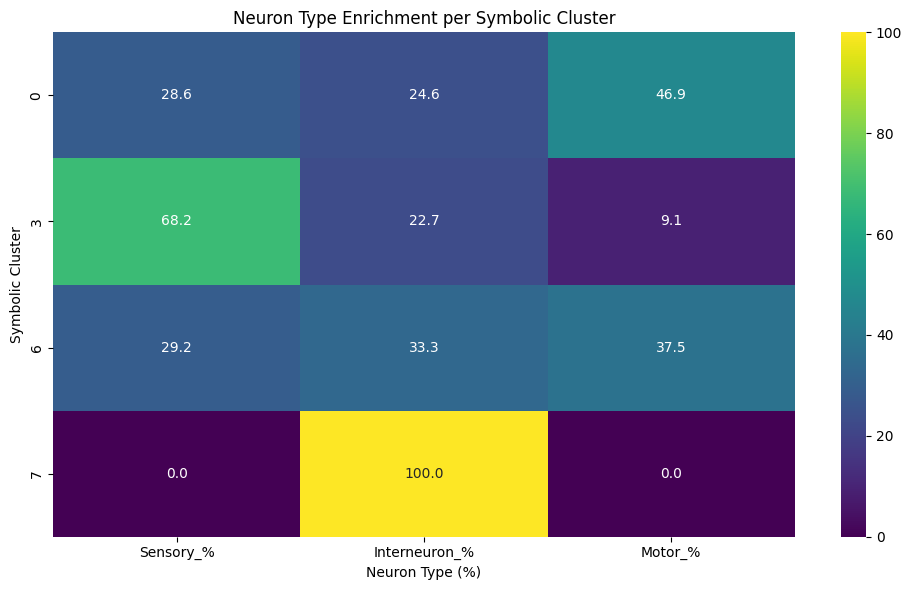

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔥 Heatmap of relative enrichment
plt.figure(figsize=(10, 6))
sns.heatmap(type_counts[["Sensory_%", "Interneuron_%", "Motor_%"]], annot=True, fmt=".1f", cmap="viridis")
plt.title("Neuron Type Enrichment per Symbolic Cluster")
plt.xlabel("Neuron Type (%)")
plt.ylabel("Symbolic Cluster")
plt.tight_layout()
plt.show()


In [92]:
# 📥 Load the canonical cluster dataframe
df = pd.read_csv("nca_symbolic_clusters_with_names.csv")

# 📌 Define symbolic role assignments based on biological type enrichment
symbolic_roles = {
    0: "Effector 🔧",        # Motor-enriched
    3: "Sensor 🧿",          # Sensory-enriched
    6: "Integrator 🧠",      # Mixed signal processor
    7: "Relay 🔁",           # 100% Interneuron (clean relay)
    1: "Unclassified ❓",
    2: "Unclassified ❓",
    4: "Unclassified ❓",
    5: "Unclassified ❓"
}

# 🏷️ Add symbolic role column
df["SymbolicRole"] = df["Cluster"].map(symbolic_roles)

# 💾 Save updated dataframe
df.to_csv("nca_symbolic_clusters_labeled.csv", index=False)

# ✅ Preview
df[["NeuronName", "Cluster", "SymbolicRole"]].head(10)


,NeuronName,Cluster,SymbolicRole
0,ADAL,0,Effector 🔧
1,ADAR,0,Effector 🔧
2,ADEL,0,Effector 🔧
3,ADER,0,Effector 🔧
4,ADF,0,Effector 🔧
5,ADFL,0,Effector 🔧
6,ADFR,0,Effector 🔧
7,ADL,0,Effector 🔧
8,ADLL,0,Effector 🔧
9,ADLR,0,Effector 🔧


In [94]:
import pandas as pd

# Load dataset
df = pd.read_csv("neuron_master.csv")

# Preview
print("✅ Loaded neuron_master.csv")
print(f"📦 Shape: {df.shape}")
print("📌 Columns:", list(df.columns))
df.head()


✅ Loaded neuron_master.csv
📦 Shape: (1533, 79)
📌 Columns: ['Neuron', 'Type', 'TotalStrength', 'AvgRelatedness', 'StrengthImbalance', 'RichClubScore', 'total_3node_motifs', 'as_source', 'as_target', 'KMeansCluster', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', 'Leiden', 'HDBSCAN_Cluster', 'LeidenRole', 'SymbolicRole', 'LatentArchetype']


,Neuron,Type,TotalStrength,AvgRelatedness,StrengthImbalance,RichClubScore,total_3node_motifs,as_source,as_target,KMeansCluster,...,59,60,61,62,63,Leiden,HDBSCAN_Cluster,LeidenRole,SymbolicRole,LatentArchetype
0,AINL,Unknown,138.0,15.316667,118.0,0.077508,378,63,23,2,...,-0.157626,-0.171714,0.037616,-0.041930,-0.119734,3,6,🧩 Integrative Hub,Unknown ❓,-1
1,AINR,Unknown,158.0,14.890244,122.0,0.087552,435,54,8,2,...,-0.036408,-0.267625,-0.057632,0.134284,-0.129003,3,6,🧩 Integrative Hub,Unknown ❓,-1
2,CEPshVR,Glia,152.0,7.323529,152.0,0.077508,300,0,35,0,...,-0.206222,-0.275492,-0.013684,0.129823,-0.210072,3,6,🧩 Integrative Hub,Glia ⚙️,-1
3,CEPshDL,Glia,57.0,8.388889,57.0,0.045153,136,0,16,0,...,-0.461325,0.169051,-0.011417,0.296840,0.273879,3,6,🧩 Integrative Hub,Glia ⚙️,-1
4,CEPshVL,Glia,132.0,7.333333,132.0,0.070775,276,0,39,0,...,-0.192025,0.008682,-0.153582,0.263449,0.004935,3,6,🧩 Integrative Hub,Glia ⚙️,-1


📊 Symbolic Role Frequencies:
SymbolicRole
Unknown ❓           1338
Glia ⚙️               43
Motor 🦴               40
Oscillator 🔁          32
Olfactory 🌬           28
Chemosensory 👃        24
Relay 🧠               16
Mechanosensory 🤚      12
Name: count, dtype: int64


/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 127788 (\N{WIND BLOWING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 128067 (\N{NOSE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52857/4083608197.py:17: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  p

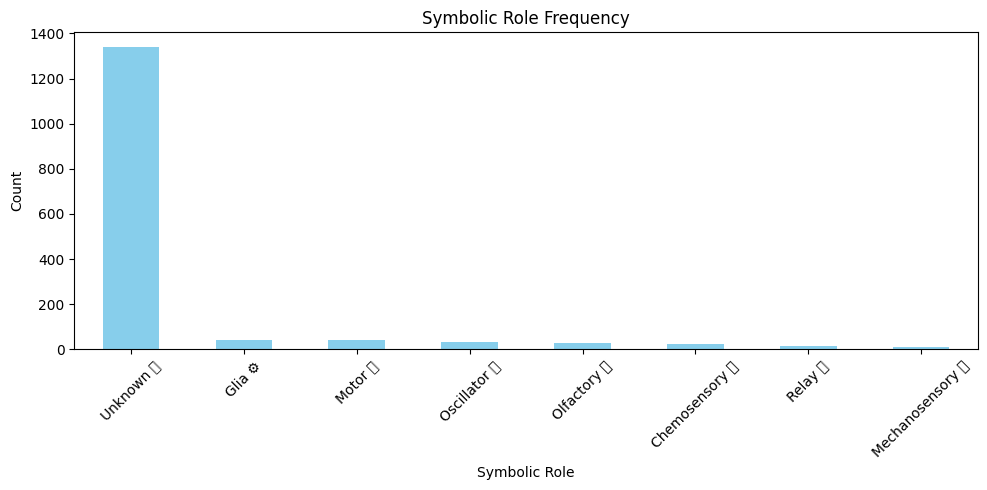

In [95]:
# Count symbolic role frequencies
role_counts = df["SymbolicRole"].value_counts().sort_values(ascending=False)

# Print role frequencies
print("📊 Symbolic Role Frequencies:")
print(role_counts)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
role_counts.plot(kind="bar", color="skyblue")
plt.title("Symbolic Role Frequency")
plt.xlabel("Symbolic Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [96]:
# Clean missing values
df["Type"] = df["Type"].fillna("Unknown")

# Crosstab
role_type_ct = pd.crosstab(df["SymbolicRole"], df["Type"])
role_type_ct["Total"] = role_type_ct.sum(axis=1)

# Normalize for %
role_type_pct = role_type_ct.div(role_type_ct["Total"], axis=0) * 100

print("🧬 Symbolic Role × Neuron Type Crosstab (%):")
display(role_type_pct.round(1))


🧬 Symbolic Role × Neuron Type Crosstab (%):


Type,Glia,Interneuron,Sensory,Unknown,Total
SymbolicRole,,,,,
Chemosensory 👃,0.0,0.0,8.3,91.7,100.0
Glia ⚙️,9.3,0.0,0.0,90.7,100.0
Mechanosensory 🤚,0.0,0.0,16.7,83.3,100.0
Motor 🦴,0.0,0.0,0.0,100.0,100.0
Olfactory 🌬,0.0,0.0,7.1,92.9,100.0
Oscillator 🔁,0.0,25.0,0.0,75.0,100.0
Relay 🧠,0.0,12.5,0.0,87.5,100.0
Unknown ❓,0.0,0.1,0.3,99.6,100.0


In [97]:
# Choose relevant numeric columns
feature_cols = [
    "TotalStrength", "AvgRelatedness", "StrengthImbalance", 
    "RichClubScore", "total_3node_motifs", "as_source", "as_target"
]

# Group by Symbolic Role
agg_stats = df.groupby("SymbolicRole")[feature_cols].mean().round(2)
print("🧠 Average Structural Features per Symbolic Role:")
display(agg_stats.sort_index())


🧠 Average Structural Features per Symbolic Role:


,TotalStrength,AvgRelatedness,StrengthImbalance,RichClubScore,total_3node_motifs,as_source,as_target
SymbolicRole,,,,,,,
Chemosensory 👃,98.42,8.65,82.08,0.04,140.25,26.12,20.71
Glia ⚙️,142.95,8.98,113.14,0.06,320.98,30.00,26.28
Mechanosensory 🤚,107.75,8.75,101.92,0.03,89.00,8.83,5.67
Motor 🦴,419.10,8.62,302.70,0.09,549.67,31.85,51.45
Olfactory 🌬,151.18,8.42,120.61,0.04,187.75,22.43,17.29
Oscillator 🔁,569.53,9.15,556.16,0.12,1093.28,11.41,33.59
Relay 🧠,409.81,8.09,306.56,0.10,747.94,95.81,83.00
Unknown ❓,147.25,6.25,134.90,0.04,150.83,11.41,9.48


In [98]:
from sklearn.preprocessing import LabelEncoder

# Encode SymbolicRole numerically
df["SymbolicRoleCode"] = LabelEncoder().fit_transform(df["SymbolicRole"])

# Correlation with features
correlations = df[feature_cols + ["SymbolicRoleCode"]].corr(method="spearman")

# Extract only SymbolicRole correlations
symbolic_corr = correlations["SymbolicRoleCode"].drop("SymbolicRoleCode").sort_values(ascending=False)

print("📉 Spearman Correlation with Symbolic Role:")
display(symbolic_corr.round(3))


📉 Spearman Correlation with Symbolic Role:


StrengthImbalance    -0.081
as_source            -0.122
TotalStrength        -0.155
as_target            -0.159
AvgRelatedness       -0.163
RichClubScore        -0.231
total_3node_motifs   -0.251
Name: SymbolicRoleCode, dtype: float64

In [100]:
# Cross-tab KMeansCluster and SymbolicRole
cluster_role_ct = pd.crosstab(df["KMeansCluster"], df["SymbolicRole"])

# Normalize rows
cluster_role_pct = cluster_role_ct.div(cluster_role_ct.sum(axis=1), axis=0) * 100

print("🧩 KMeans Cluster ↔ Symbolic Role (%):")
display(cluster_role_pct.round(1))


🧩 KMeans Cluster ↔ Symbolic Role (%):


SymbolicRole,Chemosensory 👃,Glia ⚙️,Mechanosensory 🤚,Motor 🦴,Olfactory 🌬,Oscillator 🔁,Relay 🧠,Unknown ❓
KMeansCluster,,,,,,,,
0,2.1,3.1,1.2,1.0,2.1,0.2,0.2,90.1
1,0.0,3.0,0.0,10.2,1.8,13.2,4.8,67.1
2,5.4,4.3,2.2,0.0,3.3,4.3,0.0,80.4
3,3.7,7.4,0.0,14.8,0.0,0.0,14.8,59.3
4,0.3,1.1,0.0,1.4,0.5,0.0,0.5,96.2
5,0.0,3.8,0.0,11.3,5.7,7.5,0.0,71.7


# Phase 5

In [102]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("neuron_master.csv")

# 🧹 Drop ID/meta columns that exist
drop_cols = [
    "Neuron", "SymbolicRole", "Type", "LatentArchetype",
    "LeidenRole", "KMeansCluster", "HDBSCAN_Cluster", "Leiden"
]
drop_cols = [col for col in drop_cols if col in df.columns]
X = df.drop(columns=drop_cols)

# Fill any missing values with zero
X = X.fillna(0)

# 🔠 Encode Symbolic Role labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["SymbolicRole"].fillna("Unknown ❓"))

# 🧠 Print class labels
print("🧠 Symbolic Role Classes:", list(label_encoder.classes_))


🧠 Symbolic Role Classes: ['Chemosensory 👃', 'Glia ⚙️', 'Mechanosensory 🤚', 'Motor 🦴', 'Olfactory 🌬', 'Oscillator 🔁', 'Relay 🧠', 'Unknown ❓']


In [103]:
# from sklearn.model_selection import train_test_split

# Split (stratify to preserve label distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [111]:
from xgboost import XGBClassifier
print(XGBClassifier().get_params())


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [114]:
# ✅ C. elegans Connectome Overnight Analysis Pipeline (Notebook Version)
# Requirements: Pandas, NetworkX, scikit-learn, Seaborn, Plotly, scipy

import pandas as pd
import networkx as nx
import numpy as np
from scipy.stats import entropy, hypergeom
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os
import logging
from datetime import datetime

# Setup logging
log_dir = "logs"
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(
    filename=f"{log_dir}/connectome_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Output directory
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# ✅ Load existing data from notebook context (assumed preloaded)
# G = full connectivity graph
# motif_matrix = neuron_motif_matrix
# neuron_types = df_master['Type']
# lineage_matrix = lineage_dist_matrix
# symbolic_roles = df_master['SymbolicRole']

# ✅ Task 1: Motif-Driven Functional Divergence Analysis
def motif_divergence_analysis():
    try:
        logging.info("🔍 Task 1: Motif Divergence Analysis")
        lineage_depths = lineage_matrix.mean(axis=1).round().astype(int)
        grouped = pd.concat([neuron_types.rename('type'), lineage_depths.rename('depth')], axis=1)
        results = []

        for ntype in grouped['type'].unique():
            for depth in sorted(grouped['depth'].unique()):
                mask = (grouped['type'] == ntype) & (grouped['depth'] == depth)
                if mask.sum() < 2:
                    continue
                sub = motif_matrix.loc[mask]
                mean_profile = sub.mean() + 1e-10
                kl = entropy(sub.values.T, mean_profile.values[:, None]).mean()
                results.append({"type": ntype, "depth": depth, "kl_divergence": kl})

        div_df = pd.DataFrame(results)
        div_df.to_csv(f"{output_dir}/motif_divergence.csv")

        # Heatmap
        pivot = div_df.pivot(index='type', columns='depth', values='kl_divergence')
        plt.figure(figsize=(10,6))
        sns.heatmap(pivot, annot=True, cmap='viridis')
        plt.title("KL Divergence by Type and Lineage Depth")
        plt.savefig(f"{output_dir}/motif_divergence_heatmap.png")
        plt.close()

        logging.info("✅ Task 1 complete")
    except Exception as e:
        logging.error(f"❌ Task 1 failed: {e}")


# ✅ Task 2: Synthetic Lesion Impact Ranking
def lesion_impact_ranking():
    try:
        logging.info("🔍 Task 2: Lesion Impact Ranking")
        base_cluster = nx.average_clustering(G.to_undirected())
        base_centrality = nx.betweenness_centrality(G)
        base_motif = motif_matrix.sum()
        results = []

        for neuron in G.nodes:
            G_temp = G.copy()
            if neuron not in G_temp:
                continue
            G_temp.remove_node(neuron)
            new_cluster = nx.average_clustering(G_temp.to_undirected())
            new_centrality = nx.betweenness_centrality(G_temp)
            new_motif = motif_matrix.drop(neuron, errors='ignore').sum()

            results.append({
                'neuron': neuron,
                'clustering_impact': abs(base_cluster - new_cluster),
                'centrality_impact': sum(abs(base_centrality.get(n,0) - new_centrality.get(n,0)) for n in G_temp.nodes),
                'motif_impact': abs(base_motif - new_motif).mean(),
                'type': neuron_types.get(neuron, 'unknown'),
                'symbolic_role': symbolic_roles.get(neuron, 'unknown')
            })

        impact_df = pd.DataFrame(results)
        impact_df['total_impact'] = impact_df[['clustering_impact','centrality_impact','motif_impact']].sum(axis=1)
        impact_df.sort_values('total_impact', ascending=False).to_csv(f"{output_dir}/lesion_impact_ranking.csv")

        top = impact_df.head(20)
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(G)
        nx.draw(G.subgraph(top['neuron']), pos,
                node_color=top['total_impact'], cmap='plasma', node_size=100)
        plt.title("Top 20 High-Impact Neurons")
        plt.savefig(f"{output_dir}/lesion_impact_network.png")
        plt.close()

        logging.info("✅ Task 2 complete")
    except Exception as e:
        logging.error(f"❌ Task 2 failed: {e}")


# ✅ Task 3: Lineage-Guided Motif Enrichment Flow
def motif_enrichment_flow():
    try:
        logging.info("🔍 Task 3: Motif Enrichment Flow")
        lineage_depths = lineage_matrix.mean(axis=1).round().astype(int)
        unique_depths = sorted(lineage_depths.unique())
        total_neurons = len(motif_matrix)

        results = []
        for motif in motif_matrix.columns:
            total_motif = motif_matrix[motif].sum()
            for depth in unique_depths:
                neurons_at_depth = lineage_depths[lineage_depths == depth].index
                count = motif_matrix.loc[neurons_at_depth, motif].sum()
                size = len(neurons_at_depth)
                pval = hypergeom.sf(count - 1, total_neurons, total_motif, size)
                results.append({"motif": motif, "depth": depth, "pval": pval, "count": count})

        enrich_df = pd.DataFrame(results)
        enrich_df.to_csv(f"{output_dir}/motif_enrichment.csv")

        nodes = list(map(str, unique_depths)) + list(motif_matrix.columns)
        node_map = {n:i for i,n in enumerate(nodes)}
        source, target, value = [], [], []

        for _, row in enrich_df.iterrows():
            if row['pval'] < 0.05:
                source.append(node_map[str(row['depth'])])
                target.append(node_map[row['motif']])
                value.append(row['count'])

        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=15, thickness=20, line=dict(color="black", width=0.5), label=nodes),
            link=dict(source=source, target=target, value=value)
        )])
        fig.update_layout(title_text="Motif Enrichment Flow", font_size=10)
        fig.write_html(f"{output_dir}/motif_enrichment_sankey.html")

        logging.info("✅ Task 3 complete")
    except Exception as e:
        logging.error(f"❌ Task 3 failed: {e}")


# ✅ Execute All
motif_divergence_analysis()
lesion_impact_ranking()
motif_enrichment_flow()
print("🎉 All tasks completed.")


🎉 All tasks completed.
